# Homework 5: Portfolio Construction

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import cvxpy as cp
import statsmodels.api as sm

%matplotlib inline
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)

## Loading data and checking there are no duplicate keys 

In [71]:
# Load data
data_df = pd.read_excel('data.xlsx')
factors_df = pd.read_excel('factors.xlsx')
estimates_df = pd.read_excel('estimates.xlsx')

# Normalize key dtypes first (same keys we will use for indexes) — then check uniqueness.
data_df['date'] = pd.to_datetime(data_df['date'])
factors_df['date'] = pd.to_datetime(factors_df['date'])

# --- Duplicate key checks BEFORE set_index (prevents ambiguous rows / silent drops) ---
_dup_data = data_df.duplicated(subset=['date', 'mrap_id'], keep=False)
n_dup_data = int(_dup_data.sum())
if n_dup_data:
    raise ValueError(
        f"data.xlsx: {n_dup_data} rows lie in duplicate (date, mrap_id) groups. "
        "Fix the file or dedupe before indexing."
    )

_dup_fac = factors_df.duplicated(subset=['date'], keep=False)
n_dup_fac = int(_dup_fac.sum())
if n_dup_fac:
    raise ValueError(
        f"factors.xlsx: {n_dup_fac} rows lie in duplicate date groups. "
        "Fix the file or dedupe before indexing."
    )

_dup_est = estimates_df.duplicated(subset=['mrap_id'], keep=False)
n_dup_est = int(_dup_est.sum())
if n_dup_est:
    raise ValueError(
        f"estimates.xlsx: {n_dup_est} rows lie in duplicate mrap_id groups. "
        "Fix the file or dedupe before indexing."
    )

print(
    "Duplicate-key checks passed: "
    "data (date, mrap_id), factors (date), estimates (mrap_id) are unique."
)




Duplicate-key checks passed: data (date, mrap_id), factors (date), estimates (mrap_id) are unique.


In [72]:
# Panel indices: time-first where applicable; cross-section ids on mrap_id for estimates.
factors_df = factors_df.set_index('date').sort_index()
assert factors_df.index.name == 'date'

estimates_df = estimates_df.set_index('mrap_id').sort_index()
assert estimates_df.index.name == 'mrap_id'

data_df = (
    data_df
    .set_index(['date', 'mrap_id'])
    .sort_index()
)
assert data_df.index.names == ['date', 'mrap_id']

print("data.xlsx shape (rows, cols):", data_df.shape)
print("factors.xlsx shape (rows, cols):", factors_df.shape)
print("estimates.xlsx shape (rows, cols):", estimates_df.shape)

display(data_df.head())
display(factors_df.head())
display(estimates_df.head())

data.xlsx shape (rows, cols): (95631, 5)
factors.xlsx shape (rows, cols): (108, 6)
estimates.xlsx shape (rows, cols): (1000, 5)


naics     price           vol       ret  \
date       mrap_id                                                   
2031-01-31 201     325414.000000  5.170000  18352.000000  0.102345   
           224     334516.000000 25.580000 200854.000000 -0.006584   
           377     325320.000000 51.669998 119178.000000  0.017727   
           421     541512.000000 34.259998  49790.000000 -0.058015   
           519     518210.000000 19.059999  10205.000000 -0.112663   

                          shrout  
date       mrap_id                
2031-01-31 201      30787.000000  
           224     118045.000000  
           377      66557.000000  
           421     108715.000000  
           519      29438.000000

,factor_1,factor_2,factor_3,factor_4,factor_5,rf
date,,,,,,
2031-01-31,0.019900,-0.024300,0.008200,-0.007600,0.008300,0.000100
2031-02-28,0.034900,0.016500,0.012700,-0.019400,0.008800,0.000100
2031-03-31,0.004600,0.026200,-0.018300,0.017600,-0.000300,0.000100
2031-04-29,0.029000,-0.005500,-0.024300,0.010100,-0.008000,0.000000
2031-05-31,-0.012700,-0.006200,-0.021200,0.020800,-0.015800,0.000000


,naics,price,ret,shrout,pred
mrap_id,,,,,
61,515210,28.980000,-0.045455,218693,0.065368
181,541715,45.980000,0.107952,68084,0.016078
201,325414,193.990010,0.024234,55771,0.206953
224,334510,109.590000,0.022486,123530,0.019844
377,561730,65.700000,0.179524,56692,0.021738


In [73]:
# =============================================================================
# Unit normalization — apply once here so all downstream cells use real units
# =============================================================================
# data.xlsx:     vol    is in 00's  → multiply × 100 for actual shares traded
#                shrout is in 000's → multiply × 1000 for actual shares outstanding
# estimates.xlsx shrout is in 000's → same adjustment

data_df['vol']    = data_df['vol']    * 100
data_df['shrout'] = data_df['shrout'] * 1000
estimates_df['shrout'] = estimates_df['shrout'] * 1000

print("Unit normalization applied:")
print(f"  data_df['vol']         now in actual shares  (sample max: {data_df['vol'].max():,.0f})")
print(f"  data_df['shrout']      now in actual shares  (sample max: {data_df['shrout'].max():,.0f})")
print(f"  estimates_df['shrout'] now in actual shares  (sample max: {estimates_df['shrout'].max():,.0f})")


Unit normalization applied:
  data_df['vol']         now in actual shares  (sample max: 12,703,910,900)
  data_df['shrout']      now in actual shares  (sample max: 29,206,400,000)
  estimates_df['shrout'] now in actual shares  (sample max: 15,441,881,000)


## Data quality and exploratory checks

The cells below run **independent** checks on the raw inputs (`data.xlsx`, `factors.xlsx`, `estimates.xlsx`).  
Each section has a short description and a single code cell so you can re-run or skip checks easily. **After the calendar-alignment check**, run **sample cleaning** (prices, min return-month count), then continue to the analysis section.

| # | What we check |
|---|----------------|
| 1 | Missing values by column |
| 2 | Nonsensical returns and sign issues (e.g. negative price) |
| 3 | **Return panel** — EDA plots: raw vs calendar coverage, contiguous vs interior-gap, segment counts |
| 4 | Stale / repeated prices |
| 5 | Return distribution and outliers |
| 6 | Cross-file ID coverage and NAICS in estimates |
| 7 | Calendar alignment: data vs factor dates |


### Check 1 — Missing values


In [74]:
# Check 1 — Missing values per column
print("=== Check 1: Missing values per column ===")
for name, df in [('data', data_df), ('factors', factors_df), ('estimates', estimates_df)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"\n{name}.xlsx:")
        print(missing.to_string())
    else:
        print(f"\n{name}.xlsx: no missing values")


=== Check 1: Missing values per column ===

data.xlsx:
naics     634
price     510
vol       504
ret       738
shrout    203

factors.xlsx: no missing values

estimates.xlsx: no missing values


### Check 2 — Nonsensical returns and bad inputs


In [75]:
# Check 2 — Nonsensical returns and invalid inputs
print("=== Check 2: Nonsensical returns / bad inputs ===")
print(f"Returns < -1.0 (> 100% loss) : {(data_df['ret'] < -1.0).sum()}")
print(f"Returns > 5.0 (> 500% gain): {(data_df['ret'] > 5.0).sum()}")
print(f"Negative prices              : {(data_df['price'] < 0).sum()}")
print(f"Negative volume              : {(data_df['vol'] < 0).sum()}")
print(f"Non-positive shares (shrout) : {(data_df['shrout'] <= 0).sum()}")


=== Check 2: Nonsensical returns / bad inputs ===
Returns < -1.0 (> 100% loss) : 0
Returns > 5.0 (> 500% gain): 0
Negative prices              : 30
Negative volume              : 0
Non-positive shares (shrout) : 0


**Clearly we have negative prices that we have to handle.**

### Check 3 — Return panel (raw coverage + factor-calendar continuity)

This replaces the old split between “observations per stock” and “factor-calendar gaps”. **Check 3 is exploratory:** we **classify** each `mrap_id` and **plot** return-panel shape (contiguous vs sporadic re-entry). We **do not** drop names here.

**Classification:** **(i)** raw monthly rows in the long file, **(ii)** non-missing months after aligning to the **factor calendar**, **(iii)** whether missing months are only **leading/trailing** (IPO / delist) or include **interior holes** (returns disappear then reappear). **Segment count** (`n_seg`) counts disjoint spells of valid months on the calendar—values $\geq 2$ often mean separate listed spells (e.g. delist → private → re-IPO under one id) or bad merges; we cannot tell without corporate actions.


=== Check 3: Return panel (raw + factor calendar + continuity) ===
Factor calendar length T = 108
Stocks in wide matrix: 1000

--- Classification on factor calendar ---
  Full contiguous panel (all T months observed):     771
  Partial but contiguous (IPO/delist edges only):  225
  Interior missing months (non-contiguous span):   4

--- Segment count on calendar (among interior-gap names) ---
0    1
2    3
  (n_seg >= 2: multiple disjoint spells — re-listing vs data holes.)

--- Raw file rows vs calendar non-miss (dates outside factor calendar) ---
  Stocks where raw_rows != cal_nonmiss: 229

--- Raw monthly row counts (long file) ---
count   1000.000000
mean      95.631000
std       26.822608
min        2.000000
25%      108.000000
50%      108.000000
75%      108.000000
max      108.000000

Stocks with raw_rows == 108: 778
Stocks with raw_rows < 36 : 70


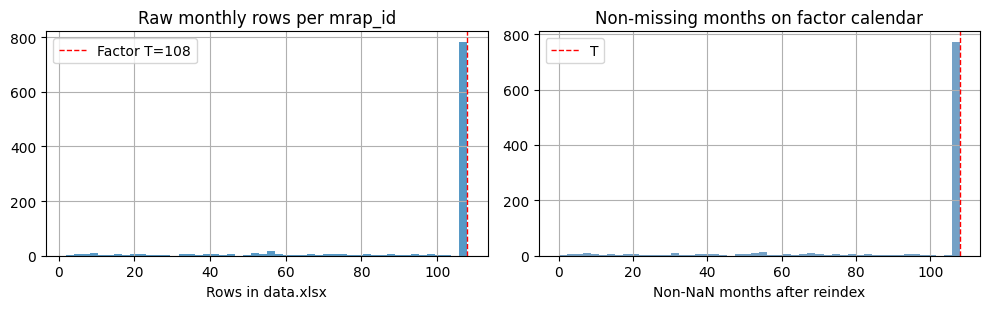

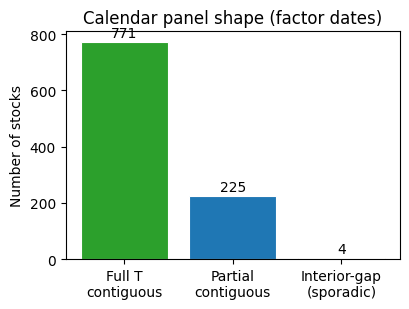

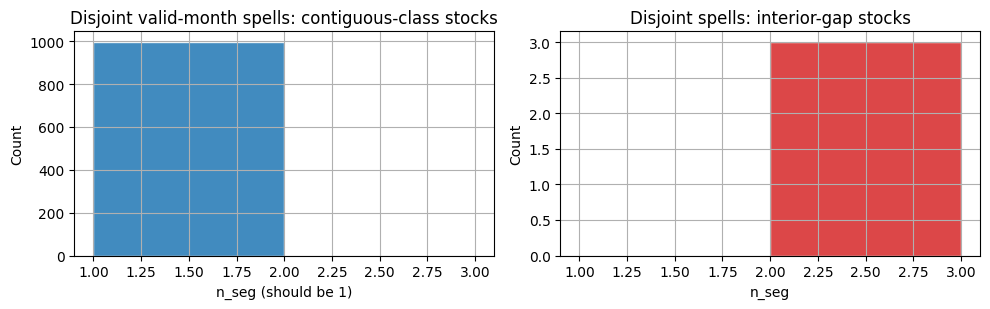

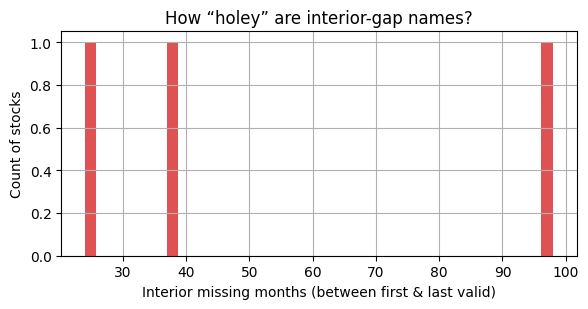

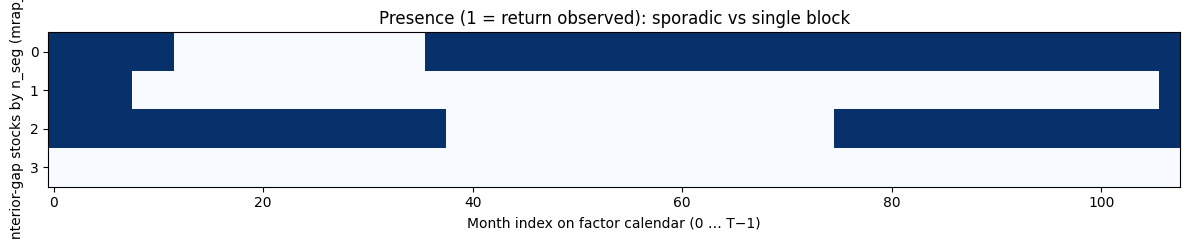

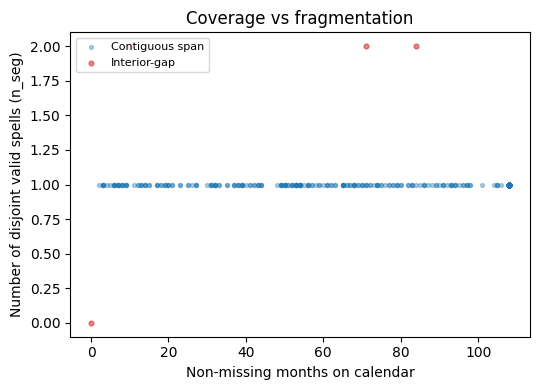

In [76]:
# Check 3 — Return panel: classify + visualize (no dropping here)

def _return_panel_has_interior_gap(row: pd.Series) -> bool:
    """True if any calendar month is missing *between* the first and last observed return."""
    v = row.notna().to_numpy()
    if not v.any():
        return True
    first = int(np.argmax(v))
    last = int(len(v) - 1 - np.argmax(v[::-1]))
    return not bool(v[first : last + 1].all())


def _count_valid_segments(row: pd.Series) -> int:
    """Number of disjoint runs of non-NaN months on the factor calendar (0 if never present)."""
    v = row.notna().to_numpy()
    if not v.any():
        return 0
    w = v.astype(np.int8)
    d = np.diff(np.r_[0, w, 0])
    return int((d == 1).sum())


def _interior_hole_months(row: pd.Series) -> float:
    """Count of missing months strictly between first and last valid return (0 if none / empty)."""
    v = row.notna().to_numpy()
    if not v.any():
        return np.nan
    first = int(np.argmax(v))
    last = int(len(v) - 1 - np.argmax(v[::-1]))
    span = v[first : last + 1]
    return float((~span).sum())


_dates_panel = sorted(factors_df.index.unique())
T_cal = len(_dates_panel)
R_wide = data_df['ret'].unstack(level='date').reindex(columns=_dates_panel)

raw_obs = data_df.groupby(level='mrap_id').size()
cal_obs = R_wide.notna().sum(axis=1)
interior_gap = R_wide.apply(_return_panel_has_interior_gap, axis=1)
n_segments = R_wide.apply(_count_valid_segments, axis=1)
hole_months = R_wide.apply(_interior_hole_months, axis=1)

both = pd.DataFrame({
    'raw_rows': raw_obs,
    'cal_nonmiss': cal_obs,
    'interior_gap': interior_gap,
    'n_seg': n_segments,
    'hole_months': hole_months,
}).reindex(R_wide.index)

mismatch = both['raw_rows'] != both['cal_nonmiss']
n_mismatch = int(mismatch.sum())

full_cal = (~interior_gap) & (both['cal_nonmiss'] == T_cal)
partial_cont = (~interior_gap) & (both['cal_nonmiss'] < T_cal)
gappy = interior_gap

print("=== Check 3: Return panel (raw + factor calendar + continuity) ===")
print(f"Factor calendar length T = {T_cal}")
print(f"Stocks in wide matrix: {len(R_wide)}")
print()
print("--- Classification on factor calendar ---")
print(f"  Full contiguous panel (all T months observed):     {int(full_cal.sum())}")
print(f"  Partial but contiguous (IPO/delist edges only):  {int(partial_cont.sum())}")
print(f"  Interior missing months (non-contiguous span):   {int(gappy.sum())}")
print()
print("--- Segment count on calendar (among interior-gap names) ---")
if gappy.any():
    sg = n_segments[gappy]
    print(sg.value_counts().sort_index().head(15).to_string())
    print("  (n_seg >= 2: multiple disjoint spells — re-listing vs data holes.)")
print()
print(f"--- Raw file rows vs calendar non-miss (dates outside factor calendar) ---")
print(f"  Stocks where raw_rows != cal_nonmiss: {n_mismatch}")
if n_mismatch and n_mismatch <= 20:
    print(both.loc[mismatch, ['raw_rows', 'cal_nonmiss']].head(20).to_string())
print()
print("--- Raw monthly row counts (long file) ---")
print(raw_obs.describe().to_string())
print(f"\nStocks with raw_rows == {T_cal}: {(raw_obs == T_cal).sum()}")
print(f"Stocks with raw_rows < 36 : {(raw_obs < 36).sum()}")

# --- Figures: panel shape (contiguous vs sporadic) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
raw_obs.hist(bins=50, ax=axes[0], edgecolor='none', alpha=0.75)
axes[0].set_title('Raw monthly rows per mrap_id')
axes[0].set_xlabel('Rows in data.xlsx')
axes[0].axvline(T_cal, color='red', ls='--', lw=1, label=f'Factor T={T_cal}')
axes[0].legend()

cal_obs.hist(bins=50, ax=axes[1], edgecolor='none', alpha=0.75, color='steelblue')
axes[1].set_title('Non-missing months on factor calendar')
axes[1].set_xlabel('Non-NaN months after reindex')
axes[1].axvline(T_cal, color='red', ls='--', lw=1, label='T')
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 3.2))
cats = ['Full T\ncontiguous', 'Partial\ncontiguous', 'Interior-gap\n(sporadic)']
counts = [int(full_cal.sum()), int(partial_cont.sum()), int(gappy.sum())]
colors = ['#2ca02c', '#1f77b4', '#d62728']
ax.bar(cats, counts, color=colors, edgecolor='white', lw=0.8)
ax.set_ylabel('Number of stocks')
ax.set_title('Calendar panel shape (factor dates)')
for i, c in enumerate(counts):
    ax.text(i, c + max(counts) * 0.01, str(c), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
if (~gappy).any():
    nmax = int(n_segments.max()) + 2
    n_segments.loc[~gappy].hist(bins=range(1, max(3, nmax)), ax=axes[0], color='#1f77b4', alpha=0.85, edgecolor='white')
    axes[0].set_title('Disjoint valid-month spells: contiguous-class stocks')
else:
    axes[0].text(0.5, 0.5, 'No contiguous-class stocks', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Contiguous-class (n_seg)')
axes[0].set_xlabel('n_seg (should be 1)')
axes[0].set_ylabel('Count')
if gappy.any():
    ub = min(20, int(n_segments[gappy].max()) + 2)
    n_segments.loc[gappy].hist(bins=range(1, max(3, ub)), ax=axes[1], color='#d62728', alpha=0.85, edgecolor='white')
    axes[1].set_title('Disjoint spells: interior-gap stocks')
else:
    axes[1].text(0.5, 0.5, 'No interior-gap stocks', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Interior-gap (n_seg)')
axes[1].set_xlabel('n_seg')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

if gappy.any():
    hm = hole_months[gappy].dropna()
    fig, ax = plt.subplots(figsize=(6, 3.2))
    hm.hist(bins=40, ax=ax, color='#d62728', alpha=0.8, edgecolor='none')
    ax.set_xlabel('Interior missing months (between first & last valid)')
    ax.set_ylabel('Count of stocks')
    ax.set_title('How “holey” are interior-gap names?')
    plt.tight_layout()
    plt.show()

    # Calendar presence: subset with most disjoint spells (read as time along x)
    k = min(30, int(gappy.sum()))
    sample_idx = n_segments[gappy].sort_values(ascending=False).head(k).index
    Z = R_wide.loc[sample_idx].notna().astype(np.float32).values
    fig, ax = plt.subplots(figsize=(12, max(2.5, k * 0.18)))
    ax.imshow(Z, aspect='auto', cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xlabel('Month index on factor calendar (0 … T−1)')
    ax.set_ylabel(f'Top {k} interior-gap stocks by n_seg (mrap_id order)')
    ax.set_title('Presence (1 = return observed): sporadic vs single block')
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4))
ok = ~(gappy) & (cal_obs > 0)
ax.scatter(cal_obs.loc[ok], n_segments.loc[ok], s=8, alpha=0.35, c='#1f77b4', label='Contiguous span')
if gappy.any():
    ax.scatter(cal_obs.loc[gappy], n_segments.loc[gappy], s=12, alpha=0.55, c='#d62728', label='Interior-gap')
ax.set_xlabel('Non-missing months on calendar')
ax.set_ylabel('Number of disjoint valid spells (n_seg)')
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Coverage vs fragmentation')
plt.tight_layout()
plt.show()


### Check 4 — Stale or repeated prices


In [77]:
# Check 5 — Stale / repeated month-end prices
print("=== Check 5: Stale prices (many identical month-end prices per stock) ===")
price_changes = data_df.groupby(level='mrap_id', sort=False)['price'].apply(
    lambda s: (s.droplevel('mrap_id').sort_index().diff().abs() < 1e-8).sum()
)
stale_stocks = price_changes[price_changes > 2]
print(f"Stocks with >2 zero price changes: {len(stale_stocks)}")
if len(stale_stocks) > 0:
    print(stale_stocks.sort_values(ascending=False).head(10))


=== Check 5: Stale prices (many identical month-end prices per stock) ===
Stocks with >2 zero price changes: 5
mrap_id
28751    5
34642    3
42988    3
66474    3
46931    3
Name: price, dtype: int64


### Check 5 — Return distribution and outliers


=== Check 6: Return distribution (data.xlsx) ===
count   94893.000000
mean        0.014904
std         0.094922
min        -0.878327
1%         -0.223495
5%         -0.125000
25%        -0.033569
50%         0.014090
75%         0.060158
95%         0.154444
99%         0.277847
max         4.163793


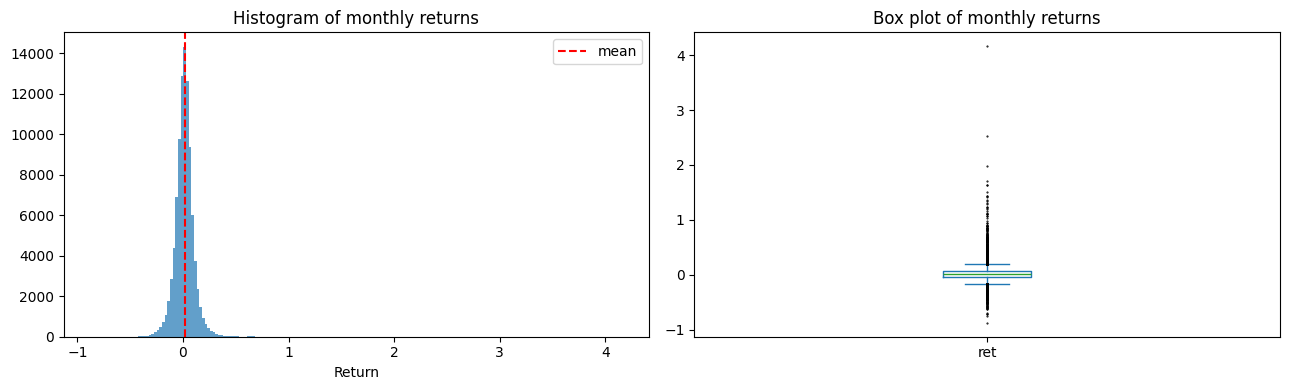

In [78]:
# Check 6 — Return distribution and extreme tails
print("=== Check 6: Return distribution (data.xlsx) ===")
ret_desc = data_df['ret'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(ret_desc.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(data_df['ret'].dropna(), bins=200, edgecolor='none', alpha=0.7)
axes[0].set_title('Histogram of monthly returns')
axes[0].set_xlabel('Return')
axes[0].axvline(data_df['ret'].mean(), color='red', ls='--', label='mean')
axes[0].legend()

data_df['ret'].dropna().plot.box(ax=axes[1], vert=True, sym='k.', flierprops=dict(markersize=1))
axes[1].set_title('Box plot of monthly returns')
plt.tight_layout()
plt.show()


### Check 6 — Cross-file ID coverage and NAICS


In [79]:
# Check 7 — Cross-file ID coverage
data_ids  = set(data_df.index.get_level_values('mrap_id').unique())
est_ids   = set(estimates_df.index.unique())
print("=== Check 7: Cross-file stock coverage ===")
print(f"Stocks in data.xlsx      : {len(data_ids)}")
print(f"Stocks in estimates.xlsx : {len(est_ids)}")
print(f"In estimates but NOT data: {sorted(est_ids - data_ids)}")
print(f"In data but NOT estimates: {len(data_ids - est_ids)} stocks")
est_naics_missing = estimates_df['naics'].isna().sum()
print(f"\nMissing NAICS in estimates.xlsx: {est_naics_missing} out of {len(estimates_df)}")


=== Check 7: Cross-file stock coverage ===
Stocks in data.xlsx      : 1000
Stocks in estimates.xlsx : 1000
In estimates but NOT data: []
In data but NOT estimates: 0 stocks

Missing NAICS in estimates.xlsx: 0 out of 1000


### Check 7 — Date alignment: data vs factors


In [80]:
# Check 8 — Date alignment: stock panel vs factor calendar
data_dates = set(data_df.index.get_level_values('date').unique())
factor_dates = set(factors_df.index.unique())
print("=== Check 8: Date alignment (data vs factors) ===")
print(f"Dates in data but not in factors : {sorted(data_dates - factor_dates)}")
print(f"Dates in factors but not in data : {sorted(factor_dates - data_dates)}")
print(f"Common dates                     : {len(data_dates & factor_dates)}")


=== Check 8: Date alignment (data vs factors) ===
Dates in data but not in factors : []
Dates in factors but not in data : []
Common dates                     : 108


### End of EDA — Sample cleaning (`data_df`)

After the checks above, we **apply one cleaning pass** before Problems 1–7 (single code cell below).

- **Negative prices:** drop the **stock–month row** (invalid bid/ask average).
- **No price history:** drop the entire **`mrap_id`** if it has **no** non-missing `price` after that step.
- **Thin return history:** drop entire **`mrap_id`** if it has **fewer than 10** non-missing **`ret`** months after aligning to the **factor calendar** (same months as `factors_df`). This keeps per-stock OLS from being run on extremely short panels later; Problem 1 only pivots what is left.
- **Not dropped here:** interior gaps in returns (IPOs, delists, possible re-listings) — we only enforce a **minimum count** of valid return months, not continuity.

The next cell updates **`data_df`** and prints counts.


In [81]:
# --- EDA cleaning: prices + thin return history (single place for sample cuts on data_df) ---
# Run after load/index (cell 4) and EDA checks. Requires factors_df for the return-month count calendar.

MIN_MONTHS_RETURNS = 10  # drop entire mrap_id if fewer than this many non-missing ret on factor dates

print("=== EDA sample cleaning (data_df) ===")
n0 = len(data_df)
ids0 = data_df.index.get_level_values("mrap_id").nunique()

# (1) Remove observations with negative reported price
neg = (data_df["price"] < 0) & data_df["price"].notna()
n_neg = int(neg.sum())
if n_neg:
    print(f"Rows with price < 0 (dropped): {n_neg}")
data_df = data_df.loc[~neg].copy()

# (2) Remove names that never have a usable price on any date
nn = data_df["price"].notna().groupby(level="mrap_id").sum()
no_price_ids = nn[nn == 0].index.tolist()
n_names = len(no_price_ids)
if n_names:
    print(f"mrap_id with no non-missing price anywhere (dropped entirely): {n_names}")
    data_df = data_df.drop(no_price_ids, level="mrap_id").copy()

# (3) Remove names with too few valid returns on the factor calendar (aligns with Problem 1 date grid)
_dates_clean = sorted(factors_df.index.unique())
_ret_wide = data_df["ret"].unstack(level="date").reindex(columns=_dates_clean)
obs_per = _ret_wide.notna().sum(axis=1)
too_few = obs_per[obs_per < MIN_MONTHS_RETURNS].index.tolist()
n_short = len(too_few)
if n_short:
    print(
        f"mrap_id with fewer than {MIN_MONTHS_RETURNS} non-missing ret on factor calendar "
        f"(dropped entirely): {n_short}"
    )
    data_df = data_df.drop(too_few, level="mrap_id").copy()

data_df = data_df.sort_index()
n1 = len(data_df)
ids1 = data_df.index.get_level_values("mrap_id").nunique()
print(f"Rows: {n0} -> {n1}  (removed {n0 - n1})")
print(f"Unique mrap_id: {ids0} -> {ids1}  (net change {ids1 - ids0})")
print("data_df shape after cleaning:", data_df.shape)


=== EDA sample cleaning (data_df) ===
Rows with price < 0 (dropped): 30
mrap_id with fewer than 10 non-missing ret on factor calendar (dropped entirely): 27
Rows: 95631 -> 95396  (removed 235)
Unique mrap_id: 1000 -> 973  (net change -27)
data_df shape after cleaning: (95396, 5)


Immediately before this note, **`data_df` was cleaned in one pass**: (i) rows with **negative `price`** removed; (ii) **`mrap_id`** with **no** non-missing **price** anywhere dropped; (iii) **`mrap_id`** with **fewer than 10** non-missing **`ret`** months on the **factor calendar** dropped. We did **not** require contiguous return panels—only a minimum **count** of valid return months.

Check 3 **visualizes** interior gaps on the factor calendar; those patterns can mean bad data or a **delist → private → re-IPO** under the same identifier. Problem 1 **does not** drop stocks for that reason.

### Data processing note - cross-section of returns and missing data

We align each stock to the **factor calendar** (the $T$ months in `factors.xlsx`). Missing returns at the **start** of that window are treated as economically plausible for a **late listing or IPO** (the name simply was not in the investable universe yet). Missing returns at the **end** are treated as plausible for a **delisting or suspension** (the name stops trading but need not have intermittent bad coverage before that).

The same **interior-gap** idea is only a **diagnostic** in Check 3: if the name were one continuous listing, you would not expect returns to vanish and reappear *between* the first and last valid months. In practice we **keep** those names in the estimation sample; per-stock OLS uses whichever months have non-missing returns.

Names with **fewer than 10** non-missing returns on the factor calendar were **already removed** in the end-of-EDA cleaning cell, so Problem 1 does not apply an extra month threshold.

Per-stock OLS uses only months with a non-missing return. Idiosyncratic covariances use **pairwise overlap** of valid months so that leading/trailing NaNs for IPOs and delistings do not shrink variances toward zero by padding with zeros.

We **do not** validate each month's return against $P_t / P_{t-1} - 1$: the provided returns are treated as **total** returns (dividends, splits, etc.) and need not match simple price changes.

## Problem 1: Estimating Factor Loadings

Using `data.xlsx` (returns matrix $R \in \mathbb{R}^{n \times T}$) and `factors.xlsx` (factor returns $F \in \mathbb{R}^{5 \times T}$, Jan 2031 -- Dec 2039), run a joint time-series regression for each stock on the five factors to estimate loadings $B \in \mathbb{R}^{n \times 5}$.

**Deliverables:**
- Plot actual vs fitted returns for MRAP IDs **8568** and **39541**
- Plot cumulative returns on the five factors

In [82]:
# Getting factors into what we need
factor_cols = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
dates_sorted = sorted(factors_df.index.unique())
T_total = len(dates_sorted)
factors_sorted = factors_df.sort_index()
rf = factors_sorted['rf'].values                        # T,

# --- create columns factor_#_rf: excess returns for each factor ---
F_excess_df = factors_sorted[factor_cols].subtract(factors_sorted['rf'], axis=0)
F_excess_df.columns = [f'{c}_rf' for c in factor_cols]

print("Excess factor returns (first 3 rows):")
display(F_excess_df.head(3))

Excess factor returns (first 3 rows):


,factor_1_rf,factor_2_rf,factor_3_rf,factor_4_rf,factor_5_rf
date,,,,,
2031-01-31,0.019800,-0.024400,0.008100,-0.007700,0.008200
2031-02-28,0.034800,0.016400,0.012600,-0.019500,0.008700
2031-03-31,0.004500,0.026100,-0.018400,0.017500,-0.000400


In [83]:
# --- factor_stock_df: dates x stocks, one column per mrap_id (excess stock returns) ---
R_pivot = data_df['ret'].unstack(level='date').reindex(columns=dates_sorted)
stock_ids = R_pivot.index.values
n = len(stock_ids)
R = R_pivot.values                                      # n x T  (NaNs where missing)
R_excess = R - rf[np.newaxis, :]                        # n x T  (excess, same NaN pattern)

factor_stock_df = pd.DataFrame(
    R_excess.T, index=dates_sorted, columns=stock_ids   # T x n
)

print(f"\nfactor_stock_df shape (dates x stocks): {factor_stock_df.shape}")
display(factor_stock_df.iloc[:3, :5])



factor_stock_df shape (dates x stocks): (108, 973)


,201,224,377,421,519
2031-01-31,0.102245,-0.006684,0.017627,-0.058115,-0.112763
2031-02-28,-0.067798,0.035866,0.091830,-0.019072,0.165692
2031-03-31,-0.224166,-0.008779,0.029809,0.065357,-0.048255


In [84]:
# --- initialize factor_loadings: indexed by mrap_id, columns = loadings + diagnostics ---
loading_cols = [f'{c}_loading' for c in factor_cols]
tstat_cols   = [f'{c}_tstat'   for c in factor_cols]
factor_loadings = pd.DataFrame(
    index=pd.Index(stock_ids, name='mrap_id'),
    columns=['alpha', 'alpha_tstat'] + loading_cols + tstat_cols + ['r_squared', 'T_obs', 'nw_lag'],
    dtype=float,
)

# --- compute factor coefficients via OLS, iterate through each sid ---
X_exc = sm.add_constant(F_excess_df.values)             # T x 6  (const + 5 excess factors)

for sid in stock_ids:
    y = factor_stock_df[sid].values                     # T, excess stock return
    valid = ~np.isnan(y)
    y_v, X_v = y[valid], X_exc[valid]

    T_i = int(valid.sum())
    nw_lag = int(np.floor(4 * (T_i / 100) ** (2 / 9)))

    res = sm.OLS(y_v, X_v).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lag})

    factor_loadings.loc[sid, 'alpha']       = res.params[0]
    factor_loadings.loc[sid, 'alpha_tstat'] = res.tvalues[0]
    factor_loadings.loc[sid, 'r_squared']   = res.rsquared
    factor_loadings.loc[sid, 'T_obs']       = T_i
    factor_loadings.loc[sid, 'nw_lag']      = nw_lag
    for j, fc in enumerate(factor_cols):
        factor_loadings.loc[sid, f'{fc}_loading'] = res.params[j + 1]
        factor_loadings.loc[sid, f'{fc}_tstat']   = res.tvalues[j + 1]

# expose as B and loadings_df so downstream cells are unchanged
F = factors_sorted[factor_cols].values.T                # 5 x T (raw factors, for Omega_F)
B = factor_loadings[loading_cols].values                # n x 5
loadings_df = factor_loadings.reset_index()             # mrap_id as column, integer index

print(f"\nfactor_loadings shape : {factor_loadings.shape}")
print(f"B matrix shape        : {B.shape}")
print("\n--- Loading summary ---")
display(factor_loadings[loading_cols + ['alpha', 'r_squared']].describe())
display(factor_loadings.head(5))



factor_loadings shape : (973, 15)
B matrix shape        : (973, 5)

--- Loading summary ---


,factor_1_loading,factor_2_loading,factor_3_loading,factor_4_loading,factor_5_loading,alpha,r_squared
count,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,1.038784,0.447537,0.005299,-0.046096,-0.077169,0.005731,0.359977
std,0.545822,0.884285,0.933975,1.664715,1.288387,0.013636,0.165656
min,-4.605633,-5.065861,-10.373068,-24.679115,-15.438156,-0.040608,0.022888
25%,0.778860,-0.014059,-0.460981,-0.468361,-0.618417,-0.000463,0.229539
50%,1.040110,0.354050,-0.050188,0.034769,0.035358,0.004514,0.347522
75%,1.307674,0.776655,0.467439,0.467307,0.586075,0.009883,0.482209
max,3.403553,10.292428,7.254493,18.731558,6.646996,0.124459,0.881580


,alpha,alpha_tstat,factor_1_loading,factor_2_loading,factor_3_loading,factor_4_loading,factor_5_loading,factor_1_tstat,factor_2_tstat,factor_3_tstat,factor_4_tstat,factor_5_tstat,r_squared,T_obs,nw_lag
mrap_id,,,,,,,,,,,,,,,
201,0.023388,2.312187,1.144548,0.528005,-1.159378,-0.666517,0.437123,3.417740,0.815606,-2.105010,-0.871677,0.518868,0.156833,108.000000,4.000000
224,0.003342,0.736796,1.045449,0.184228,-0.468082,-0.620176,-0.359225,7.538451,0.865954,-2.214561,-1.958740,-1.313237,0.504478,108.000000,4.000000
377,0.005458,0.993583,0.721503,0.418483,0.584277,0.195260,-0.385032,3.132341,1.488542,1.984235,0.523538,-0.830157,0.250625,108.000000,4.000000
421,0.010005,1.389366,0.826389,0.704816,0.762949,-1.643777,-1.031668,3.913311,1.704442,1.635862,-2.564623,-1.116406,0.403062,108.000000,4.000000
519,0.002051,0.372085,1.108132,0.279857,-0.295776,0.158838,-0.030584,5.921666,0.767565,-0.932601,0.317999,-0.058041,0.270044,108.000000,4.000000


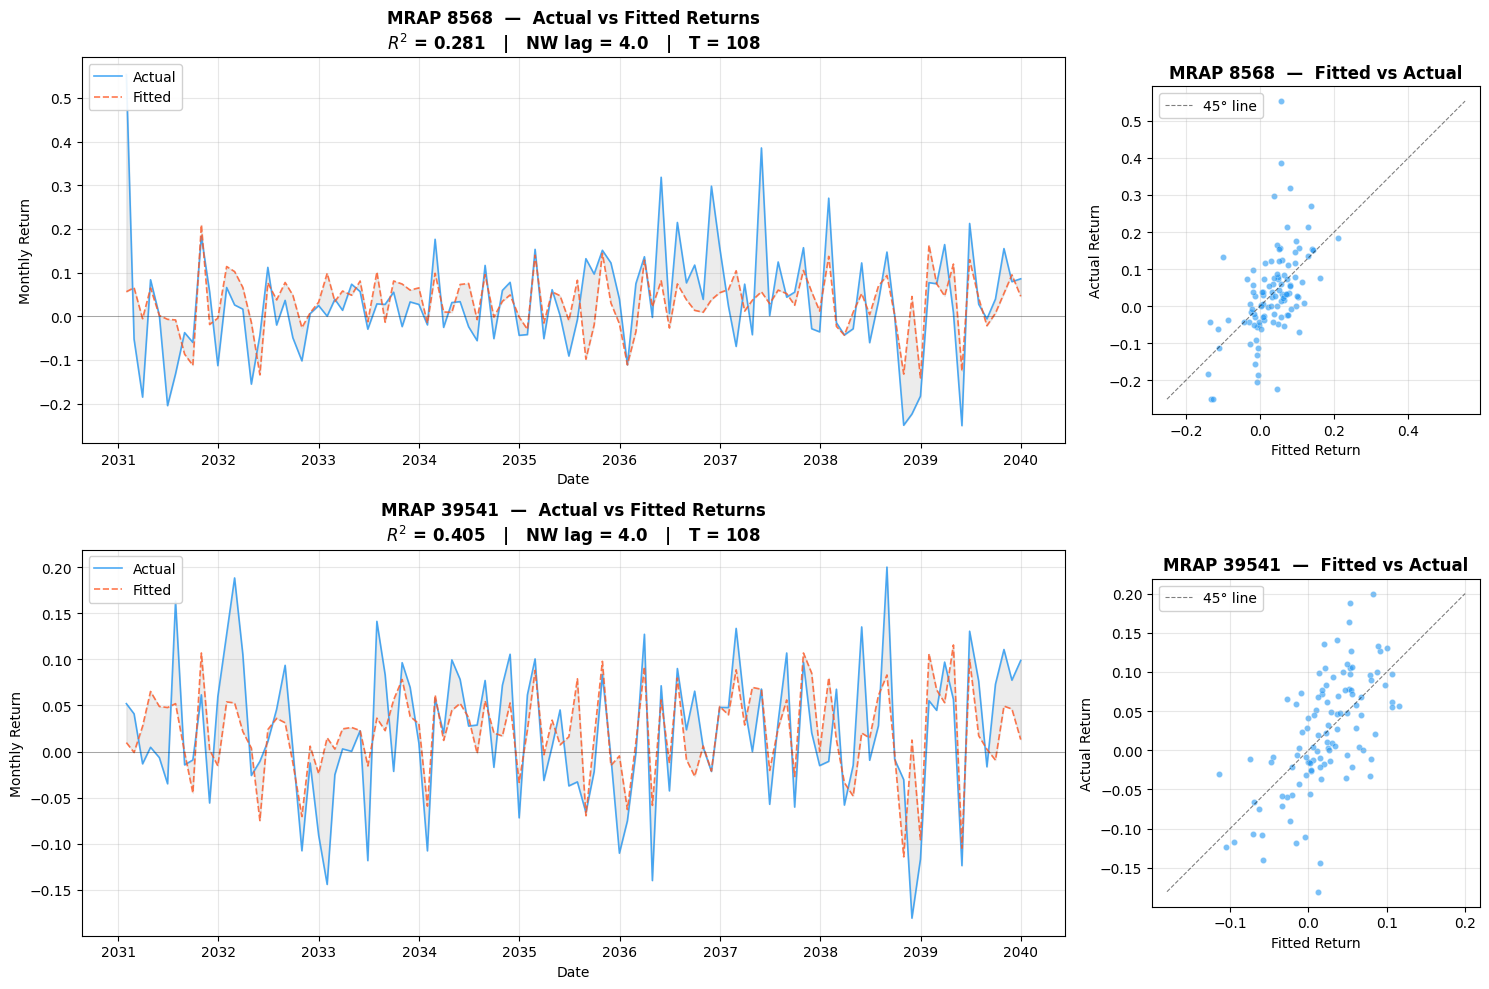

In [85]:
# --- Problem 1: Plot actual vs fitted returns for MRAP IDs 8568 and 39541 ---

plot_ids = [8568, 39541]
dates_arr = pd.to_datetime(dates_sorted)

fig, axes = plt.subplots(len(plot_ids), 2, figsize=(15, 5 * len(plot_ids)),
                         gridspec_kw={'width_ratios': [3, 1]})

for row_idx, sid in enumerate(plot_ids):
    loc = loadings_df.index[loadings_df['mrap_id'] == sid][0]
    stock_idx = np.where(stock_ids == sid)[0][0]

    y_actual = R[stock_idx, :]
    alpha_i = loadings_df.loc[loc, 'alpha']
    b_i = B[stock_idx, :]
    y_fitted = alpha_i + F.T @ b_i                 # T,

    valid = ~np.isnan(y_actual)
    r2 = loadings_df.loc[loc, 'r_squared']
    nw = loadings_df.loc[loc, 'nw_lag']
    t_obs = int(loadings_df.loc[loc, 'T_obs'])

    # --- Time-series plot ---
    ax = axes[row_idx, 0]
    ax.plot(dates_arr[valid], y_actual[valid], color='#2196F3', alpha=0.8,
            linewidth=1.2, label='Actual')
    ax.plot(dates_arr[valid], y_fitted[valid], color='#FF5722', alpha=0.8,
            linewidth=1.2, linestyle='--', label='Fitted')
    ax.fill_between(dates_arr[valid], y_actual[valid], y_fitted[valid],
                    color='grey', alpha=0.15)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_title(f'MRAP {sid}  —  Actual vs Fitted Returns\n'
                 f'$R^2$ = {r2:.3f}   |   NW lag = {nw}   |   T = {t_obs}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly Return')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)

    # --- Scatter plot ---
    ax2 = axes[row_idx, 1]
    ax2.scatter(y_fitted[valid], y_actual[valid], s=20, alpha=0.6,
                color='#2196F3', edgecolors='white', linewidth=0.3)
    lims = [min(y_actual[valid].min(), y_fitted[valid].min()),
            max(y_actual[valid].max(), y_fitted[valid].max())]
    ax2.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='45° line')
    ax2.set_title(f'MRAP {sid}  —  Fitted vs Actual', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Fitted Return')
    ax2.set_ylabel('Actual Return')
    ax2.legend(loc='upper left', framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

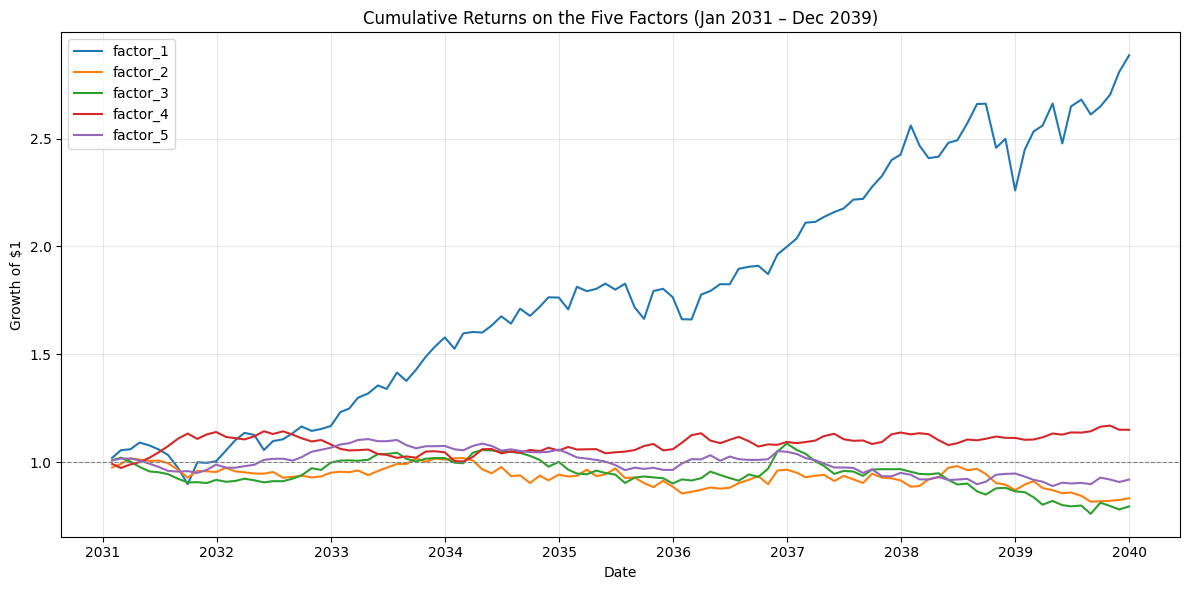


Final value of $1 invested in each factor:
  factor_1: $2.8861  (total return: 188.61%)
  factor_2: $0.8329  (total return: -16.71%)
  factor_3: $0.7950  (total return: -20.50%)
  factor_4: $1.1503  (total return: 15.03%)
  factor_5: $0.9194  (total return: -8.06%)


In [86]:
# --- Problem 1: Plot cumulative returns on the five factors ---

factor_returns = factors_sorted[factor_cols]
cumulative = (1 + factor_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for col in factor_cols:
    ax.plot(cumulative.index, cumulative[col], label=col)

ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Returns on the Five Factors (Jan 2031 – Dec 2039)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal value of $1 invested in each factor:")
for col in factor_cols:
    print(f"  {col}: ${cumulative[col].iloc[-1]:.4f}  "
          f"(total return: {(cumulative[col].iloc[-1] - 1)*100:.2f}%)")

## Problem 2: Computing the Idiosyncratic Returns and Covariance

Compute the residual returns $\varepsilon = R - BF$ and the idiosyncratic covariance $\Omega_\varepsilon = E[\varepsilon \varepsilon^T]$.

In [87]:
# --- Problem 2: Compute idiosyncratic returns and covariance ---

BF = B @ F                          # n x T  (fitted factor contribution)
epsilon = R - BF                    # n x T  (residual returns, NaN where R is NaN)

# Pairwise covariance over months where BOTH stocks have valid returns (handles IPO/delist edges).
M = ~np.isnan(R)
Omega_epsilon = np.zeros((n, n))
for i in range(n):
    for j in range(i, n):
        mask = M[i] & M[j]
        cnt = int(mask.sum())
        if cnt == 0:
            v = 0.0
        else:
            ei = R[i, mask] - BF[i, mask]
            ej = R[j, mask] - BF[j, mask]
            v = float(ei @ ej) / cnt
        Omega_epsilon[i, j] = Omega_epsilon[j, i] = v

print(f"epsilon shape      : {epsilon.shape}")
print(f"Omega_epsilon shape: {Omega_epsilon.shape}")
print(f"NaN entries in epsilon: {np.isnan(epsilon).sum()}")
print(f"\nOmega_epsilon diagonal (first 10 idiosyncratic variances):")
print(np.diag(Omega_epsilon)[:10])

epsilon shape      : (973, 108)
Omega_epsilon shape: (973, 973)
NaN entries in epsilon: 10372

Omega_epsilon diagonal (first 10 idiosyncratic variances):
[0.0145438  0.00195285 0.0033314  0.00543118 0.00444164 0.00255253
 0.00213635 0.00517943 0.00267053 0.00500123]


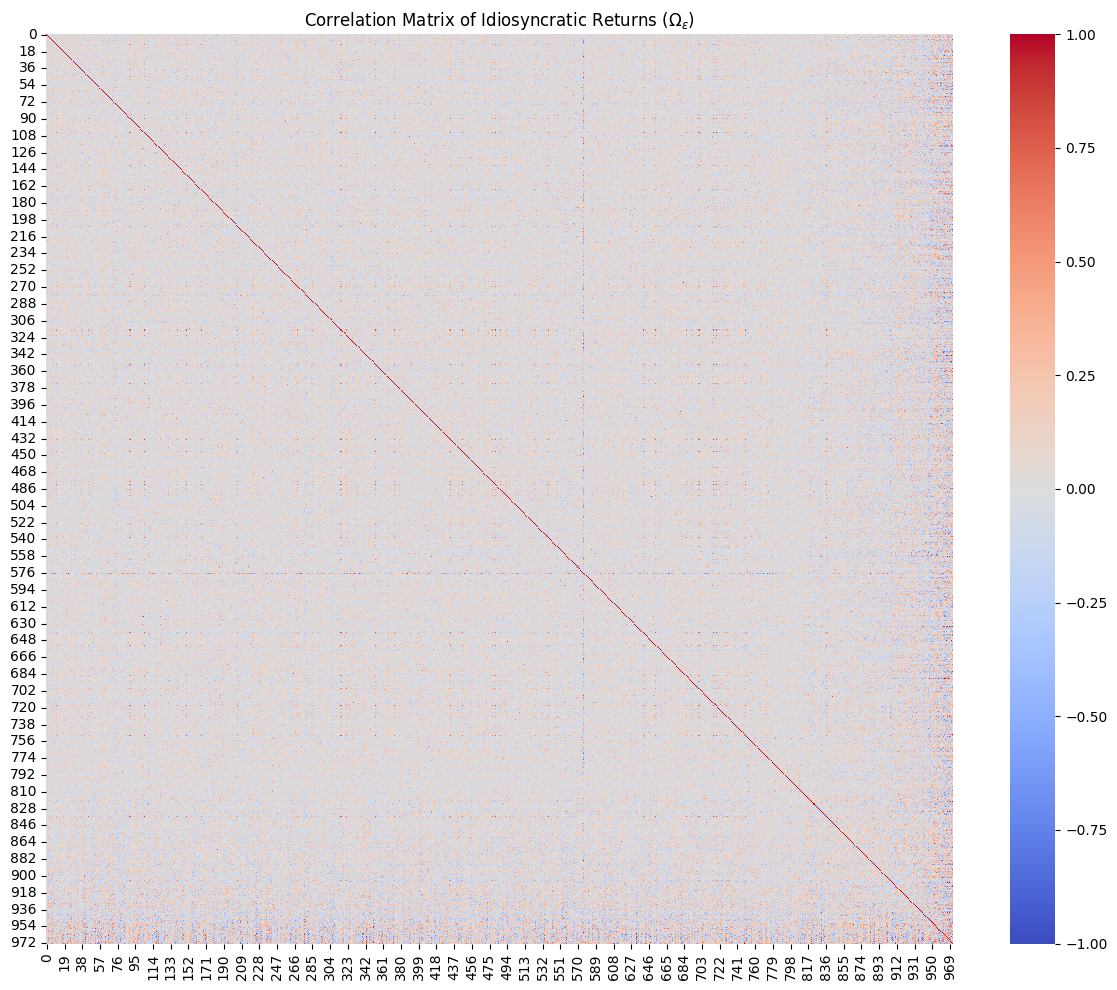

In [88]:
# Correlation matrix of idiosyncratic returns
std_eps = np.sqrt(np.diag(Omega_epsilon))
# Avoid division by zero for any stock with zero residual variance
std_eps = np.where(std_eps == 0, 1e-10, std_eps)
corr_epsilon = Omega_epsilon / np.outer(std_eps, std_eps)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_epsilon, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix of Idiosyncratic Returns ($\\Omega_\\varepsilon$)')
plt.tight_layout()
plt.show()

### Written Answer: What is the role of the matrix product $BF$? What is it doing?

The matrix product $BF$ represents the systematic (factor-explained) component of each stock's returns. Specifically, $B$ is an $n \times 5$ matrix of factor loadings and $F$ is a $5 \times T$ matrix of factor returns, so the product $BF$ yields an $n \times T$ matrix where each entry is the portion of a given stock's return, in a given month, that can be attributed to the five common factors.

By subtracting this systematic component from the total observed returns ($\varepsilon = R - BF$), we isolate the idiosyncratic returns — the part of each stock's return that is not explained by exposure to the common factors. These residuals capture stock-specific risk and form the basis for estimating the idiosyncratic covariance matrix $\Omega_\varepsilon$.

## Problem 3: Calculating the Factor Covariance Matrix

Compute $\Omega_F = E[FF^T]$ and plot the heatmap of correlations between the 5 factors.

Factor covariance matrix (Omega_F):
[[ 1.322e-03  2.770e-04  4.800e-05 -1.490e-04 -1.040e-04]
 [ 2.770e-04  5.160e-04  1.070e-04 -1.640e-04  1.000e-06]
 [ 4.800e-05  1.070e-04  5.030e-04 -3.400e-05  1.940e-04]
 [-1.490e-04 -1.640e-04 -3.400e-05  2.300e-04  2.100e-05]
 [-1.040e-04  1.000e-06  1.940e-04  2.100e-05  2.060e-04]]

Omega_F shape: (5, 5)


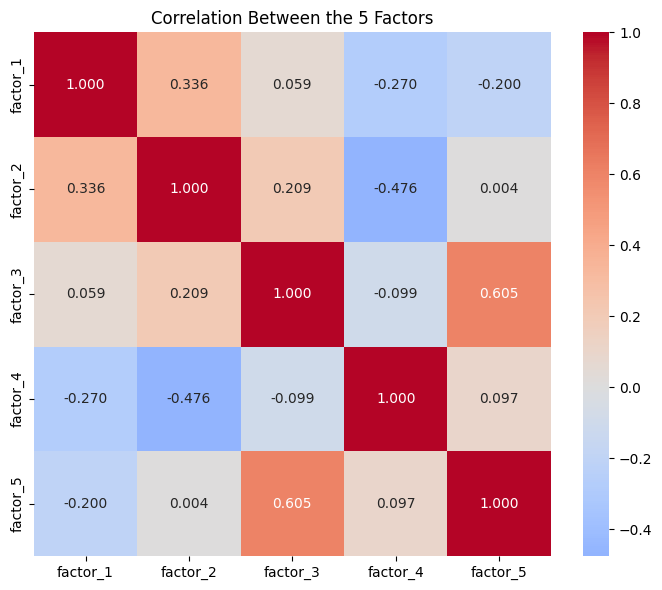


Most correlated pair: factor_3 & factor_5  (correlation = 0.6047)


In [89]:
# --- Problem 3: Factor covariance matrix and correlation heatmap ---

Omega_F = (F @ F.T) / T_total        # 5 x 5

# Convert covariance to correlation
std_f = np.sqrt(np.diag(Omega_F))
corr_F = Omega_F / np.outer(std_f, std_f)

print("Factor covariance matrix (Omega_F):")
print(np.round(Omega_F, 6))
print(f"\nOmega_F shape: {Omega_F.shape}")

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_F, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=factor_cols, yticklabels=factor_cols, ax=ax)
ax.set_title('Correlation Between the 5 Factors')
plt.tight_layout()
plt.show()

# Most correlated pair
mask = np.triu(np.ones_like(corr_F, dtype=bool), k=1)
corr_vals = np.where(mask, np.abs(corr_F), 0)
i, j = np.unravel_index(corr_vals.argmax(), corr_vals.shape)
print(f"\nMost correlated pair: {factor_cols[i]} & {factor_cols[j]}  "
      f"(correlation = {corr_F[i, j]:.4f})")

### Written Answer: Which pair of factors are most correlated?

The most correlated pair of factors are 3 and 5.

## Problem 4: Constructing the Overall Covariance Matrix of Returns

Combine loadings, factor covariance, and idiosyncratic covariance: $\Omega_R = B\,\Omega_F\,B^T + \Omega_\varepsilon$.

**Deliverables:**
- Heatmap of the correlation matrix of returns
- Report estimated correlation between MRAP IDs **24541** and **91309**

Omega_R shape: (973, 973)


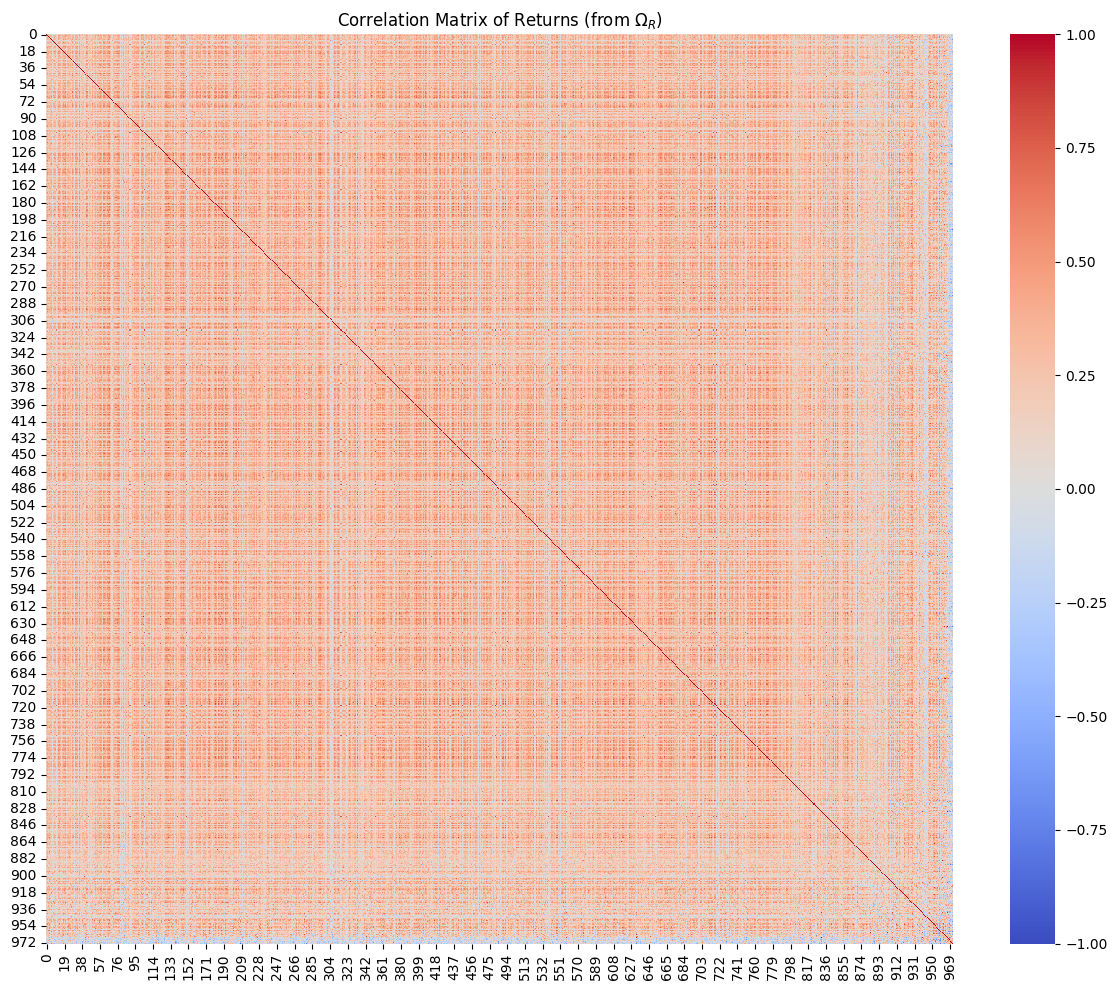


Estimated correlation between MRAP 24541 and 91309: 0.8805


In [90]:
# --- Problem 4: Overall covariance matrix ---

Omega_R = B @ Omega_F @ B.T + Omega_epsilon   # n x n

# Convert to correlation matrix
std_r = np.sqrt(np.diag(Omega_R))
corr_R = Omega_R / np.outer(std_r, std_r)

print(f"Omega_R shape: {Omega_R.shape}")

# Heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_R, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix of Returns (from $\\Omega_R$)')
plt.tight_layout()
plt.show()

# Report correlation between MRAP IDs 24541 and 91309
id_24541 = np.where(stock_ids == 24541)[0][0]
id_91309 = np.where(stock_ids == 91309)[0][0]
rho = corr_R[id_24541, id_91309]
print(f"\nEstimated correlation between MRAP 24541 and 91309: {rho:.4f}")

### Written Answer: What errors could have happened in the construction of this covariance matrix? What could be improved?

**YOUR ANSWER:**
1. Simplification to a 5-factor model that doesn't capture potentially higher order covariances not explained directly by the 5-factor model, there may be other factors that are important to consider the cross-section fo stock-returns, this would lead to OMVB in the regressions and could be a source of errors. Further it would also mean that we are incorrectly forcing the diagonal entries of the residual covariances matrix to be diagnoal when there could be real resdiual cross correlation given the five factors fail to capture the true cross section of stock returns. **Improvement:** consider how well the factors explain the cross section of returns and add other factors that can help explain the cross section but are still statistically significant. 
2. Also how do we know that the returns data is accurate? We have several consecutive months with the exact same stock price, negative stock prices and missing data. **Improvement:** Actually go into the data and fill in these values correctly. 
3. A true covariance matrix should be positive semi-definite, however we can see that it is not in this case so we can tell that the factor reconstruction of covariances don't accurately represent the true covariances. 



## Problem 5: Setting Up Portfolio Construction for January 2041

Expected returns for January 2041 are provided in `estimates.xlsx` (column `pred`).

In [104]:
# --- Problem 5: Load expected returns for Jan 2041 ---

# Align estimates (indexed by mrap_id) to the stock universe used in B and Omega_R
est_aligned = estimates_df.reindex(stock_ids)

mu = est_aligned['pred'].values             # n, expected returns
r_realized = est_aligned['ret'].values      # n, realized returns for Jan 2041
naics_codes = est_aligned['naics'].values   # n, for sector analysis later
avg_volume = data_df.groupby(level='mrap_id')['vol'].mean().reindex(stock_ids).values  # n, avg monthly shares traded

# Sector map: first 2 digits of NAICS
sector_map = (naics_codes // 10000).astype(int)

print(f"mu shape        : {mu.shape}")
print(f"r_realized shape: {r_realized.shape}")
print(f"NaN in mu       : {np.isnan(mu).sum()}")
print(f"NaN in r_realized: {np.isnan(r_realized).sum()}")
print(f"\nExpected return stats:")
print(pd.Series(mu).describe())
print(f"\nRealized return stats:")
print(pd.Series(r_realized).describe())
print(f"\nUnique sectors: {sorted(set(sector_map[~np.isnan(naics_codes)].astype(int)))}")


# Max tradeable weight per stock for a $100M book: 2% of avg monthly volume * price / 100M
# avg_volume is in actual shares (unit normalization applied above in cell 723e99b1)
latest_price_p7 = est_aligned['price'].values            # Jan 2041 price from estimates.xlsx
vol_dollar_cap  = 0.02 * avg_volume * latest_price_p7    # max $ tradeable per stock
vol_weight_cap  = vol_dollar_cap / 100_000_000           # as fraction of $100M book
# Stocks with NaN volume (no history) -> no volume constraint; position cap alone applies
vol_weight_cap  = np.where(np.isfinite(vol_weight_cap), vol_weight_cap, np.inf)

print(f"\nVolume liquidity cap (vol_weight_cap) as fraction of $100M book:")
_fin = vol_weight_cap[np.isfinite(vol_weight_cap)]
print(f"  mean  : {_fin.mean():.6f}")
print(f"  median: {np.median(_fin):.6f}")
print(f"  min   : {_fin.min():.6f}")
print(f"  max   : {_fin.max():.6f}")
print(f"  # with no volume data (inf bound): {np.sum(~np.isfinite(vol_weight_cap))}")


mu shape        : (973,)
r_realized shape: (973,)
NaN in mu       : 0
NaN in r_realized: 0

Expected return stats:
count   973.000000
mean      0.042812
std       0.161804
min      -0.771934
25%      -0.010605
50%       0.023078
75%       0.066886
max       1.536505
dtype: float64

Realized return stats:
count   973.000000
mean      0.055718
std       0.132225
min      -0.340053
25%      -0.003724
50%       0.041997
75%       0.100546
max       2.191798
dtype: float64

Unique sectors: [np.int64(21), np.int64(22), np.int64(23), np.int64(31), np.int64(32), np.int64(33), np.int64(42), np.int64(44), np.int64(45), np.int64(48), np.int64(49), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(61), np.int64(62), np.int64(71), np.int64(72), np.int64(81), np.int64(92)]

Volume liquidity cap (vol_weight_cap) as fraction of $100M book:
  mean  : 1.335633
  median: 0.415629
  min   : 0.004260
  max   : 68.159231
  # with no volume data (inf bound): 0


### Written Answer: Describe how you could forecast expected returns for January 2041 if the estimates were not provided.

**YOUR ANSWER:**

If the expected return estimates were not provided, there are several approaches one could take to forecast expected returns for January 2041:

1. **Factor-based expected returns** — Using the estimated factor loadings $B$ from Problem 1, one could forecast the expected factor premia (e.g., using historical averages or time-series models) and compute $\hat{\mu} = B \hat{f}$, where $\hat{f}$ is the vector of forecasted factor returns.

2. **Cross-sectional alpha models** — Regress future realized returns on lagged stock characteristics such as momentum (past 12-month return), value (book-to-market ratio), size (market capitalization), profitability, and investment. The fitted values from this cross-sectional regression serve as expected return forecasts.

3. **Time-series models** — Fit ARIMA or similar models to each stock's individual return series, using the 108 months of historical data to extrapolate one step ahead.

4. **Machine learning approaches** — Use gradient-boosted trees, random forests, or neural networks trained on lagged features (past returns, factor exposures, fundamentals) to predict the next month's return for each stock.

5. **Fundamental / analyst-based approaches** — Use discounted cash flow (DCF) models or analyst consensus earnings forecasts to derive implied expected returns from current prices and projected cash flows.

## Problem 6: Assumptions of Mean-Variance Optimization

List at least five implicit assumptions underlying mean-variance optimization when constructing portfolios.

### Written Answer: Five (or more) implicit assumptions of MVO

**YOUR ANSWER:**

1. **Investors care only about mean and variance** — Utility is fully characterized by the first two moments of the return distribution. Higher moments (skewness, kurtosis) are ignored, which may be inappropriate for assets with fat-tailed or asymmetric return distributions.

2. **Expected returns and covariances are known** — MVO treats $\mu$ and $\Omega$ as if they are the true population parameters, when in reality they are noisy estimates. Small errors in expected returns can produce dramatically different optimal portfolios.

3. **Returns are normally distributed** — The mean-variance framework is equivalent to expected utility maximization only under normality (or quadratic utility). In practice, asset returns exhibit fat tails and skewness.

4. **Single-period framework** — The optimization is static and considers only one holding period. It does not account for multi-period effects such as rebalancing costs, time-varying opportunities, or compounding.

5. **Frictionless markets** — MVO assumes no transaction costs, no taxes, no market impact, and unlimited liquidity. In reality, trading large positions moves prices and incurs costs that erode realized returns.

6. **Unlimited short selling** — The basic formulation allows arbitrary short positions, which may be unrealistic given borrowing constraints, short-sale restrictions, and the cost of maintaining short positions.

7. **All assets are perfectly divisible and liquid** — The optimizer assumes any fractional position size is feasible and can be executed at the prevailing market price.

8. **Stationarity** — The estimated parameters ($\mu$, $\Omega$) are assumed to be stable over the investment horizon. In practice, expected returns and covariances change over time.

9. **Sufficient history per stock** — Loadings are noisier when a stock has few valid months; we require at least 10 observed return months on the factor calendar, enforced in the **EDA cleaning** cell (see the data-processing note); IPO- and delisting-style missing months are fine wherever they occur. Panels near that cutoff still imply more estimation risk in $B$ and in $\Omega_\varepsilon$.

## Problem 7: Portfolio Optimization and Performance Evaluation

Construct dollar-neutral long-short portfolios. Use **10% annualized** as the upper bound on portfolio volatility.

For each variant, report:
- Portfolio stock weights (sorted plot + distribution)
- Portfolio realized return and expected return
- Exposure to each of the 5 factors
- Exposure to sectors {52, 33, 32, 51, 54, 53, 22, 21, 56, 31}

In [92]:
# --- Problem 7: Reporting helper function ---

FACTOR_LABELS_7 = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']


def report_portfolio(weights, mu, realized_ret, Omega_R, B,
                     factor_labels=FACTOR_LABELS_7, label="Portfolio"):
    w   = np.asarray(weights,      dtype=float).ravel()
    mu  = np.asarray(mu,           dtype=float).ravel()
    r   = np.asarray(realized_ret, dtype=float).ravel()
    B   = np.asarray(B,            dtype=float)
    Sig = np.asarray(Omega_R,      dtype=float)

    gross     = float(np.sum(np.abs(w)))
    exp_ret   = float(w @ mu)
    realized  = float(w @ r)
    month_var = float(w @ Sig @ w)
    month_vol = np.sqrt(max(month_var, 0.0))
    ann_vol   = month_vol * np.sqrt(12.0)

    # Return on gross: P&L per $1 gross exposure — natural unit for dollar-neutral L/S
    rog      = exp_ret  / gross if gross > 1e-12 else float('nan')
    rog_real = realized / gross if gross > 1e-12 else float('nan')
    rog_ann  = rog * 12         if gross > 1e-12 else float('nan')
    sharpe   = rog_ann / ann_vol if ann_vol > 1e-12 else float('nan')

    fac_exp = w @ B

    print(f"\n========== {label} ==========")
    print(f"  Return on gross (exp.)    : {rog:.6f}/mo  ({rog_ann*100:.2f}% ann.)   [= mu\'w / sum|wi|]")
    print(f"  Return on gross (realized): {rog_real:.6f}/mo  ({rog_real*12*100:.2f}% ann.)")
    print(f"  Volatility                : {month_vol:.6f}/mo  ({ann_vol*100:.2f}% ann.)")
    print(f"  Annualised Sharpe         : {sharpe:.4f}")
    print(f"  Gross exposure sum|wi|    : {gross:.4f}")
    print("\n  Factor exposures (w\'B):")
    for name, val in zip(factor_labels, fac_exp):
        print(f"    {name:10s}: {val:+.6f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(np.sort(w), color='steelblue', lw=1.2)
    axes[0].axhline(0, color='k', lw=0.5)
    axes[0].set_title(f'{label}: sorted weights')
    axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Weight')
    axes[1].hist(w, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    axes[1].axvline(0, color='k', lw=0.6)
    axes[1].set_title(f'{label}: weight distribution')
    axes[1].set_xlabel('Weight'); axes[1].set_ylabel('Count')
    plt.tight_layout()
    plt.show()


### 7(a) Unconstrained Optimization

No additional constraints beyond dollar neutrality and 10% annualized vol cap.

In [93]:
# --- 7(a): Unconstrained MVO (dollar-neutral + 10% annualized vol cap only) ---
# Monthly returns: annualized vol sqrt(12)*sigma_month <= 0.10  =>  w' Sigma w <= 0.10^2/12

from scipy.linalg import null_space

n_p7 = len(mu)
mu_p7 = np.asarray(mu, dtype=float).ravel()
r_p7 = np.asarray(r_realized, dtype=float).ravel()
if not (np.isfinite(mu_p7).all() and np.isfinite(r_p7).all()):
    raise ValueError("mu or r_realized has NaN/inf; align estimates to stock_ids before Problem 7.")

Sigma_raw = np.asarray(Omega_R, dtype=float)
sym_err = float(np.max(np.abs(Sigma_raw - Sigma_raw.T)))
Sigma_sym = (Sigma_raw + Sigma_raw.T) / 2.0
eig_pre = np.linalg.eigvalsh(Sigma_sym)
min_eig_pre = float(eig_pre.min())
max_eig_pre = float(eig_pre.max())

print("=== Omega_R diagnostics (before PSD eigenvalue clipping) ===")
print(f"  Symmetry (raw): max |Omega_R - Omega_R^T| = {sym_err:.3e}")
if sym_err < 1e-8:
    print("    -> symmetric to machine precision.")
elif sym_err < 1e-5:
    print("    -> tiny asymmetry (floating-point); symmetrizing is harmless.")
else:
    print("    -> unusually large skew; worth inspecting how Omega_R is built.")

_psd_tol = 1e-9 * max(1.0, max_eig_pre)
n_below_tol = int(np.sum(eig_pre < -_psd_tol))
print(f"  min(lambda) = {min_eig_pre:.3e}, max(lambda) = {max_eig_pre:.3e}")
print(f"  PSD? {n_below_tol == 0}  (# eigenvalues below -{_psd_tol:.1e}: {n_below_tol})")

# PSD projection: clip negative eigenvalues
evals, evecs = np.linalg.eigh(Sigma_sym)
evals_clipped = np.maximum(evals, 1e-8 * max(float(np.max(evals)), 1.0))
Sigma_eff = evecs @ (evals_clipped[:, None] * evecs.T)
Sigma_eff = (Sigma_eff + Sigma_eff.T) / 2.0

VOL_ANNUAL_CAP = 0.10
var_month_cap = (VOL_ANNUAL_CAP ** 2) / 12.0


def _w_max_mu_dollar_neutral_vol_closed_form(mu_vec, Sig, var_cap):
    """max mu' w  s.t.  sum w = 0,  w' Sig w <= var_cap  (Sig SPD). KKT on null_space(1)."""
    n = mu_vec.size
    N = null_space(np.ones((1, n)))
    if N.size == 0:
        return np.zeros(n)
    Qz = N.T @ Sig @ N
    muz = N.T @ mu_vec
    Qz = (Qz + Qz.T) / 2.0
    ev, U = np.linalg.eigh(Qz)
    ev = np.maximum(ev, 1e-12)
    Qz_spd = U @ (ev[:, None] * U.T)
    d = np.linalg.solve(Qz_spd, muz)
    denom = float(muz @ d)
    if denom <= 1e-30 or float(np.linalg.norm(muz)) < 1e-30:
        return np.zeros(n)
    alpha = np.sqrt(var_cap / denom)
    return N @ (alpha * d)


w = cp.Variable(n_p7)
constraints_7a = [cp.sum(w) == 0, cp.quad_form(w, Sigma_eff) <= var_month_cap]
objective_7a = cp.Maximize(mu_p7 @ w)
prob_7a = cp.Problem(objective_7a, constraints_7a)

_last_err = None
w_7a = None
for _name in ("SCS", "CLARABEL", "OSQP", None):
    try:
        if _name is None:
            prob_7a.solve(verbose=False)
        else:
            prob_7a.solve(solver=_name, verbose=False)
    except Exception as _e:
        _last_err = _e
        continue
    if w.value is not None and prob_7a.status in ("optimal", "optimal_inaccurate"):
        w_7a = np.asarray(w.value, dtype=float).ravel()
        break

if w_7a is None:
    w_7a = _w_max_mu_dollar_neutral_vol_closed_form(mu_p7, Sigma_eff, var_month_cap)

print(f"\n7(a) status: {getattr(prob_7a, 'status', None)!r}  |  mu'w = {float(mu_p7 @ w_7a):.6f}")
print(f"Check: sum(w)={w_7a.sum():.2e}  |  w'Sigma_eff w = {float(w_7a @ Sigma_eff @ w_7a):.6e} (cap {var_month_cap:.6e})")


=== Omega_R diagnostics (before PSD eigenvalue clipping) ===
  Symmetry (raw): max |Omega_R - Omega_R^T| = 1.388e-17
    -> symmetric to machine precision.
  min(lambda) = -1.174e-01, max(lambda) = 2.349e+00
  PSD? False  (# eigenvalues below -2.3e-09: 199)

7(a) status: 'optimal'  |  mu'w = 887.547050
Check: sum(w)=-1.05e-07  |  w'Sigma_eff w = 8.333333e-04 (cap 8.333333e-04)


### 7(a) Extended: Multiple Optimization Approaches

Six portfolio variants across two regimes — **(1) Convex** using `Sigma_eff` (PSD-projected, cvxpy) and **(2) Non-convex** using `Sigma_sym` (original indefinite matrix, scipy SLSQP). Within each: **(i)** blind max-return, **(ii)** max Sharpe Ratio, **(iii)** risk-aversion sweep λ ∈ {0, 0.5, 1, 2, 5, 10}.

#### 1. Convex Optimization (PSD-projected Σ_eff, cvxpy)

All three variants use `Sigma_eff` (eigenvalue-clipped, guaranteed PSD). The feasible set `{w : w'Σw ≤ cap, Σw = 0}` is convex, and cvxpy finds the global optimum.


========== Convex Blind max-return (Sigma_eff) ==========
  Return on gross (exp.)    : 0.250900/mo  (301.08% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005330/mo  (6.40% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 30.1080
  Gross exposure sum|wi|    : 3537.4543

  Factor exposures (w'B):
    factor_1  : +15.063129
    factor_2  : -32.775627
    factor_3  : -21.415100
    factor_4  : -35.292917
    factor_5  : +56.934534


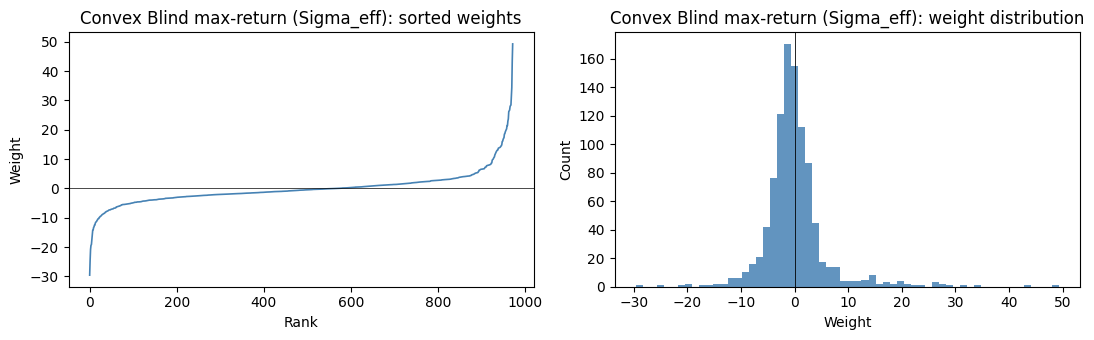

In [94]:
# --- Convex 1(i): Blind max-return (w_7a already solved above) ---
report_portfolio(w_7a, mu_p7, r_p7, Sigma_eff, B,
                 label="Convex Blind max-return (Sigma_eff)")



========== Convex Sharpe Ratio (Sigma_eff) ==========
  Return on gross (exp.)    : 0.250900/mo  (301.08% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005330/mo  (6.40% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 30.1080
  Gross exposure sum|wi|    : 3537.4542

  Factor exposures (w'B):
    factor_1  : +15.063129
    factor_2  : -32.775627
    factor_3  : -21.415100
    factor_4  : -35.292917
    factor_5  : +56.934534


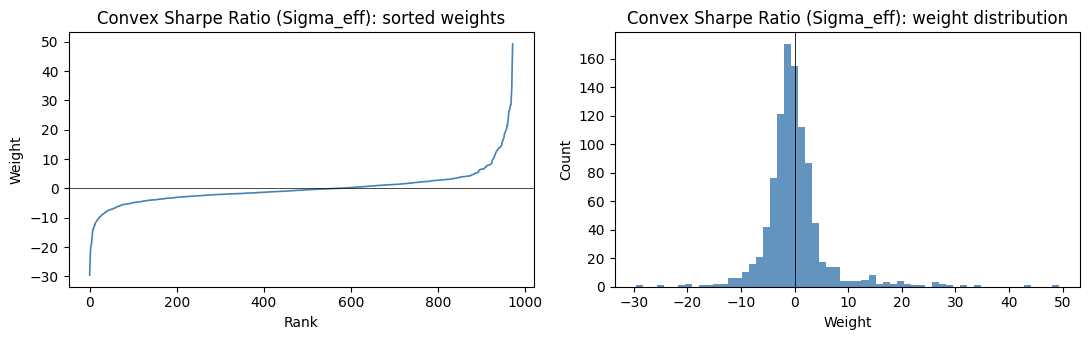

  Solver status: optimal


In [95]:
# --- Convex 1(ii): Sharpe Ratio via Charnes-Cooper (Sigma_eff, cvxpy) ---
# Charnes-Cooper: max μ'y  s.t.  y'Σy ≤ 1, sum(y)=0
# Gives the max-SR direction; scale y* to the vol cap to get w*.

y = cp.Variable(n_p7)
prob_sr_cvx = cp.Problem(
    cp.Maximize(mu_p7 @ y),
    [cp.sum(y) == 0, cp.quad_form(y, Sigma_eff) <= 1.0]
)
for _s in ("CLARABEL", "SCS", None):
    try:
        prob_sr_cvx.solve(solver=_s, verbose=False) if _s else prob_sr_cvx.solve(verbose=False)
    except Exception:
        continue
    if y.value is not None and prob_sr_cvx.status in ("optimal", "optimal_inaccurate"):
        break

y_star = np.asarray(y.value, dtype=float).ravel()
y_var  = float(y_star @ Sigma_eff @ y_star)
w_cvx_sr = y_star * np.sqrt(var_month_cap / max(y_var, 1e-12))

report_portfolio(w_cvx_sr, mu_p7, r_p7, Sigma_eff, B,
                 label="Convex Sharpe Ratio (Sigma_eff)")
print(f"  Solver status: {prob_sr_cvx.status}")



========== Convex risk-aversion λ=0.5 (Sigma_eff) ==========
  Return on gross (exp.)    : 0.250900/mo  (301.08% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005330/mo  (6.40% ann.)
  Volatility                : 30745.531448/mo  (10650564.51% ann.)
  Annualised Sharpe         : 0.0000
  Gross exposure sum|wi|    : 3767588438.6184

  Factor exposures (w'B):
    factor_1  : +16043083.179326
    factor_2  : -34907892.915530
    factor_3  : -22808290.628935
    factor_4  : -37588948.557015
    factor_5  : +60638492.525226


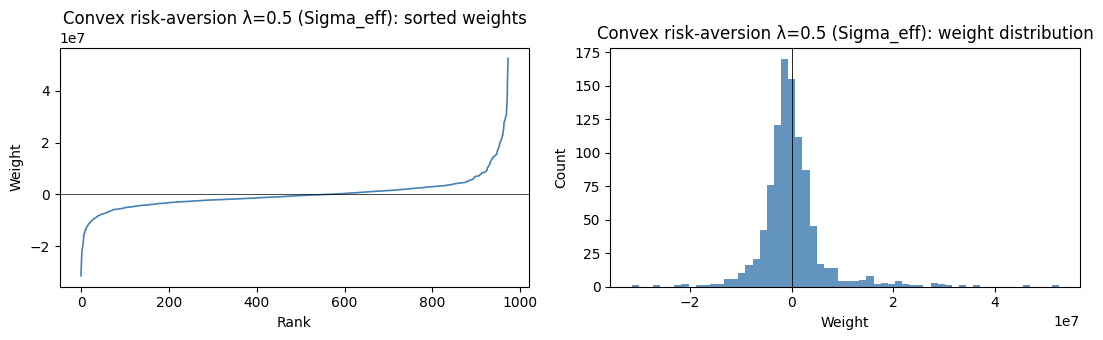


========== Convex risk-aversion λ=1 (Sigma_eff) ==========
  Return on gross (exp.)    : 0.250900/mo  (301.08% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005330/mo  (6.40% ann.)
  Volatility                : 15372.765775/mo  (5325282.27% ann.)
  Annualised Sharpe         : 0.0001
  Gross exposure sum|wi|    : 1883794225.4636

  Factor exposures (w'B):
    factor_1  : +8021541.638088
    factor_2  : -17453946.531044
    factor_3  : -11404145.380379
    factor_4  : -18794474.290181
    factor_5  : +30319246.403853


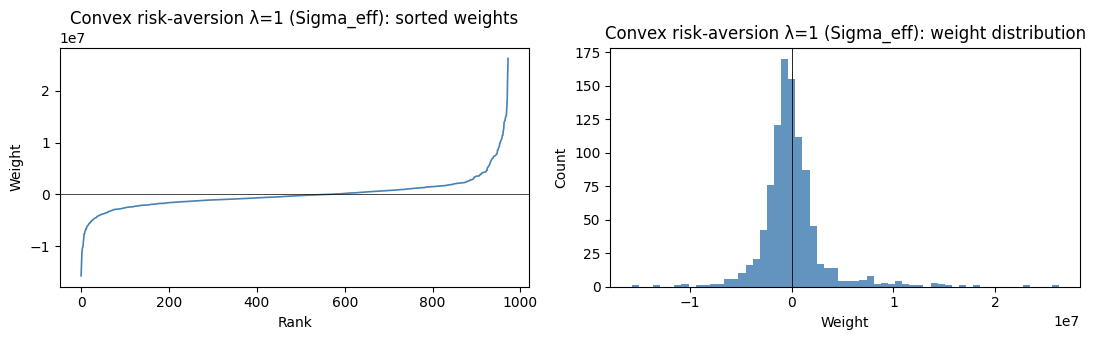


========== Convex risk-aversion λ=2 (Sigma_eff) ==========
  Return on gross (exp.)    : 0.250900/mo  (301.08% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005330/mo  (6.40% ann.)
  Volatility                : 7686.382828/mo  (2662641.12% ann.)
  Annualised Sharpe         : 0.0001
  Gross exposure sum|wi|    : 941897105.4688

  Factor exposures (w'B):
    factor_1  : +4010770.787169
    factor_2  : -8726973.200173
    factor_3  : -5702072.653222
    factor_4  : -9397237.093859
    factor_5  : +15159623.105899


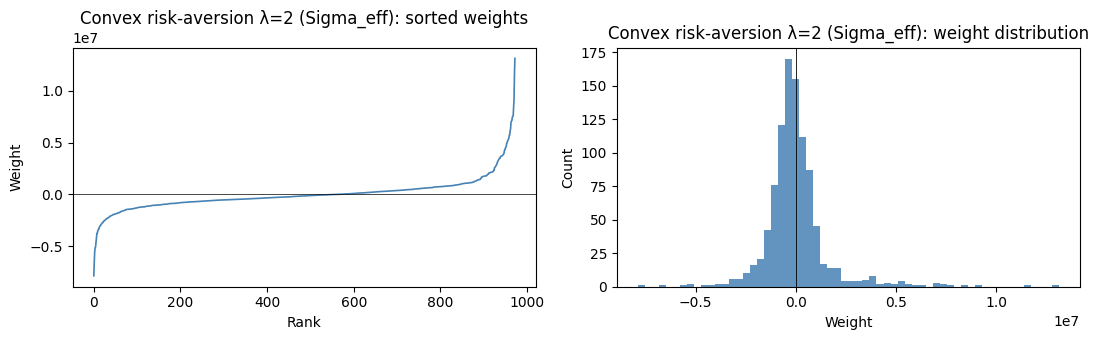


========== Convex risk-aversion λ=5 (Sigma_eff) ==========
  Return on gross (exp.)    : 0.250900/mo  (301.08% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005330/mo  (6.40% ann.)
  Volatility                : 3074.553130/mo  (1065056.45% ann.)
  Annualised Sharpe         : 0.0003
  Gross exposure sum|wi|    : 376758842.0673

  Factor exposures (w'B):
    factor_1  : +1604308.313057
    factor_2  : -3490789.265811
    factor_3  : -2280829.058803
    factor_4  : -3758894.818022
    factor_5  : +6063849.233017


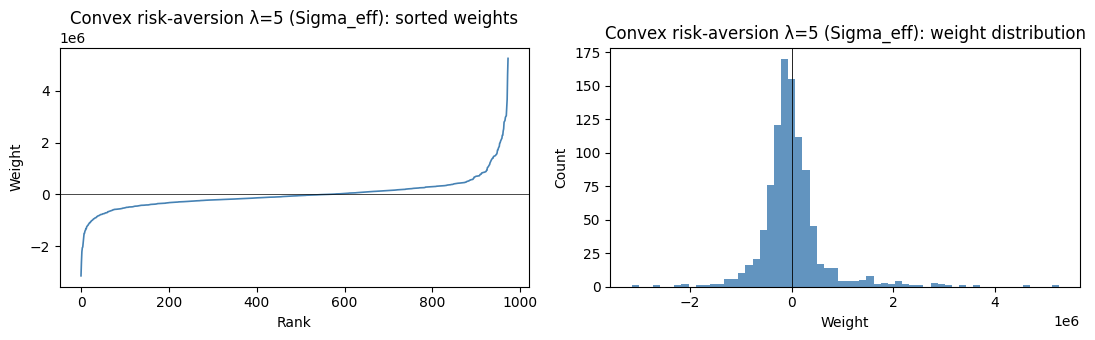


========== Convex risk-aversion λ=10 (Sigma_eff) ==========
  Return on gross (exp.)    : 0.250900/mo  (301.08% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005330/mo  (6.40% ann.)
  Volatility                : 1537.276568/mo  (532528.22% ann.)
  Annualised Sharpe         : 0.0006
  Gross exposure sum|wi|    : 188379421.4322

  Factor exposures (w'B):
    factor_1  : +802154.154703
    factor_2  : -1745394.629350
    factor_3  : -1140414.532525
    factor_4  : -1879447.416426
    factor_5  : +3031924.621921


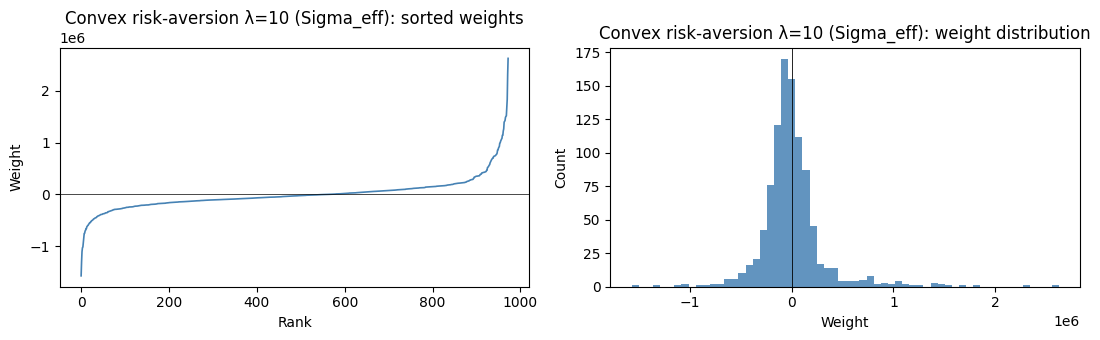

In [96]:
# --- Convex 1(iii): Risk-aversion λ sweep (Sigma_eff, cvxpy) ---
# No vol cap — λ alone controls risk. λ=0 is unbounded so we start at 0.5.
# As λ increases the optimal variance shrinks, tracing the efficient frontier.

for lam in [0.5, 1, 2, 5, 10]:
    w_ra = cp.Variable(n_p7)
    prob_ra = cp.Problem(
        cp.Maximize(mu_p7 @ w_ra - lam * cp.quad_form(w_ra, Sigma_eff)),
        [cp.sum(w_ra) == 0]
    )
    for _s in ("CLARABEL", "SCS", None):
        try:
            prob_ra.solve(solver=_s, verbose=False) if _s else prob_ra.solve(verbose=False)
        except Exception:
            continue
        if w_ra.value is not None and prob_ra.status in ("optimal", "optimal_inaccurate"):
            break
    if w_ra.value is not None:
        report_portfolio(w_ra.value, mu_p7, r_p7, Sigma_eff, B,
                         label=f"Convex risk-aversion λ={lam} (Sigma_eff)")
    else:
        print(f"λ={lam}: solver failed (status={prob_ra.status})")


#### 2. Non-Convex Optimization (original Σ_sym, scipy SLSQP)

`Sigma_sym` is symmetrized but **not** eigenvalue-clipped — it retains negative eigenvalues, so `w'Σw` is non-convex and cvxpy cannot be used. `scipy` SLSQP solves the KKT conditions numerically with no global optimality guarantee; 5 random restarts mitigate local minima.

In [97]:
# --- Non-convex setup: SLSQP constraints + multi-restart helper ---
import time
from scipy.optimize import minimize as _sp_minimize

_nc_constraints = [
    {'type': 'eq',   'fun': lambda w: w.sum()},
    {'type': 'ineq', 'fun': lambda w: var_month_cap - w @ Sigma_sym @ w},
]

def _make_cb(obj_fn, label, interval=15):
    state = {'last': time.time(), 'itr': 0}
    def cb(w):
        state['itr'] += 1
        now = time.time()
        if now - state['last'] >= interval:
            val, grad = obj_fn(w)
            gnorm = np.linalg.norm(grad)
            print(f"  [{label}] iter {state['itr']:4d}  obj={val:.6f}  ||grad||={gnorm:.2e}", flush=True)
            state['last'] = now
    return cb

def _slsqp_best(obj_and_grad, n_restarts=5, tag=""):
    best_w, best_val = None, float('inf')
    for k in range(n_restarts):
        w0 = np.random.randn(n_p7)
        w0 -= w0.mean()
        denom = abs(w0 @ Sigma_sym @ w0)
        if denom > 1e-12:
            w0 *= np.sqrt(var_month_cap / denom) * 0.9
        cb = _make_cb(obj_and_grad, f"{tag} restart {k+1}/{n_restarts}")
        res = _sp_minimize(obj_and_grad, w0, jac=True, method='SLSQP',
                           callback=cb,
                           constraints=_nc_constraints,
                           options={'maxiter': 3000, 'ftol': 1e-10})
        flag = "OK" if res.success else "WARN"
        print(f"  [{tag}] restart {k+1}/{n_restarts} — {flag}  obj={res.fun:.6f}  iters={res.nit}", flush=True)
        if res.fun < best_val:
            best_w, best_val = res.x, res.fun
    return best_w


In [ ]:
# --- Non-convex 2(i): Blind max-return (Sigma_sym) ---
def _obj_blind_nc(w):
    return -mu_p7 @ w, -mu_p7

w_nc_blind = _slsqp_best(_obj_blind_nc, tag="blind")
report_portfolio(w_nc_blind, mu_p7, r_p7, Sigma_sym, B,
                 label="NC Blind max-return (Sigma_sym)")


  [SR] restart 1/5 — WARN  obj=-13872364801129859886646320418367706062887630502088440902066775507757045241417955923589158940261642780862762080115810417552238710269326666878119051264.000000  iters=9


/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_49513/2334610945.py:7: RuntimeWarning: overflow encountered in multiply
  grad = (-mu_p7 / vol) + (ret / vol**3) * (Sigma_sym @ w)


  [SR] restart 2/5 — WARN  obj=-172940825083376218329798452164077756833150455687473353816210181879218629069340549829555825528508906342652862519508315534995039193281211507020001396450270380032.000000  iters=12
  [SR restart 3/5] iter   29  obj=129.923655  ||grad||=4.46e-16
  [SR] restart 3/5 — WARN  obj=129.923655  iters=57
  [SR] restart 4/5 — WARN  obj=-21933970164896906122321903343466025428550630494327037149693582541826426923393989680542603450942219589609418718464285326320777673244976725666183370020304715776.000000  iters=9
  [SR] restart 5/5 — WARN  obj=-621895334.927182  iters=6

========== NC Sharpe Ratio (Sigma_sym) ==========
  Return on gross (exp.)    : 0.156711/mo  (188.05% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.002534/mo  (3.04% ann.)
  Volatility                : 0.000000/mo  (0.00% ann.)
  Annualised Sharpe         : nan
  Gross exposure sum|wi|    : 11035663514004862303820078701756310914574202028887941936368771118477276166289431916345682901741184803883

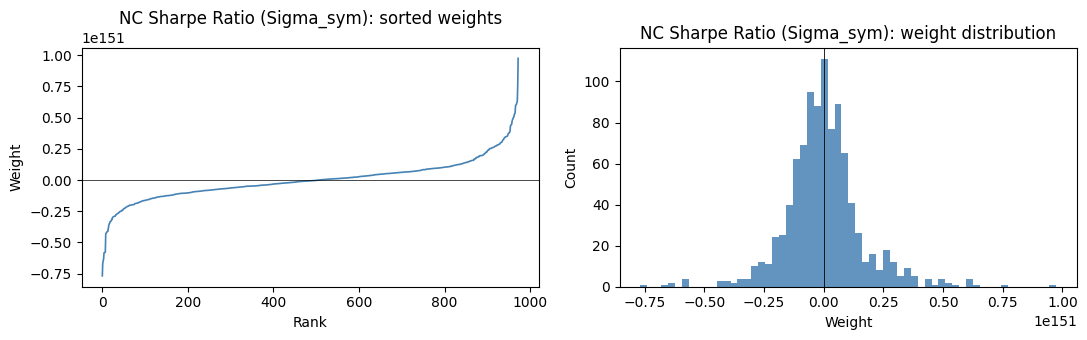

In [99]:
# --- Non-convex 2(ii): Sharpe Ratio (Sigma_sym) ---
def _obj_sr_nc(w):
    ret  = mu_p7 @ w
    var  = w @ Sigma_sym @ w
    vol  = np.sqrt(max(var, 1e-12))
    val  = -ret / vol
    grad = (-mu_p7 / vol) + (ret / vol**3) * (Sigma_sym @ w)
    return val, grad

w_nc_sr = _slsqp_best(_obj_sr_nc, tag="SR")
report_portfolio(w_nc_sr, mu_p7, r_p7, Sigma_sym, B,
                 label="NC Sharpe Ratio (Sigma_sym)")


In [ ]:
# --- Non-convex 2(iii): Risk-aversion λ sweep (Sigma_sym) ---
# No vol cap — λ alone controls risk (same reasoning as convex case).

_nc_constraints_ra = [{'type': 'eq', 'fun': lambda w: w.sum()}]

def _slsqp_best_ra(obj_and_grad, n_restarts=5, tag=""):
    best_w, best_val = None, float('inf')
    for k in range(n_restarts):
        w0 = np.random.randn(n_p7); w0 -= w0.mean(); w0 /= (np.linalg.norm(w0) + 1e-12)
        cb = _make_cb(obj_and_grad, f"{tag} restart {k+1}/{n_restarts}")
        res = _sp_minimize(obj_and_grad, w0, jac=True, method='SLSQP',
                           callback=cb,
                           constraints=_nc_constraints_ra,
                           options={'maxiter': 3000, 'ftol': 1e-10})
        flag = "OK" if res.success else "WARN"
        print(f"  [{tag}] restart {k+1}/{n_restarts} — {flag}  obj={res.fun:.6f}  iters={res.nit}", flush=True)
        if res.fun < best_val:
            best_w, best_val = res.x, res.fun
    return best_w

for lam in [0.5, 1, 2, 5, 10]:
    def _obj_ra_nc(w, l=lam):
        val  = -(mu_p7 @ w - l * w @ Sigma_sym @ w)
        grad = -(mu_p7 - 2*l * (Sigma_sym @ w))
        return val, grad
    w_nc_ra = _slsqp_best_ra(_obj_ra_nc, tag=f"RA lam={lam}")
    report_portfolio(w_nc_ra, mu_p7, r_p7, Sigma_sym, B,
                     label=f"NC risk-aversion λ={lam} (Sigma_sym)")


### Written Answer (7a): Do you notice any patterns or potential issues in the results?

**YOUR ANSWER:**


### 7(b) Position Constraints

Assume a **\$100M portfolio**. Cannot trade more than **2% of average historical monthly volume** for any security.

In [105]:
# --- 7(b): Flat position cap setup ---
# Constraints: sum(w)=0, w'Sigma_eff w <= var_month_cap, |w_i| <= POS_CAP for all i
# (vol_weight_cap computed in Problem 5 will be used in 7(g))

print("7(b) position cap sub-problems: 1%  |  50 bps  |  10%")


7(b) vol-based bound coverage (vol_weight_cap vs position caps):
  stocks where vol cap < 0.5%  (50 bps): 1
  stocks where vol cap < 1%          : 3
  stocks where vol cap < 10%         : 132
  stocks with no vol data (inf bound): 0


7(b)(i) status: optimal  |  mu'w=0.818268
  sum(w)=1.67e-16  max|w|=0.010000  # active bounds: 963

========== 7(b)(i) max_w=1% ==========
  Return on gross (exp.)    : 0.084733/mo  (101.68% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.014110/mo  (16.93% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 10.1680
  Gross exposure sum|wi|    : 9.6570

  Factor exposures (w'B):
    factor_1  : -0.058721
    factor_2  : +0.234493
    factor_3  : +0.350581
    factor_4  : +0.058085
    factor_5  : -0.843162


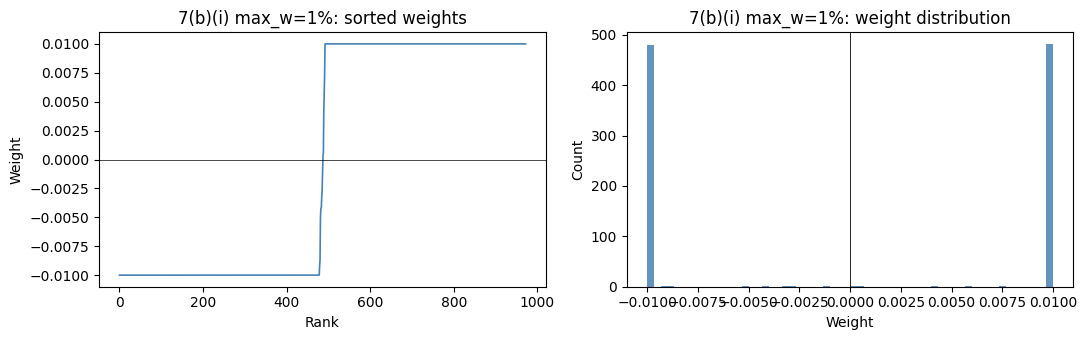

In [106]:
# --- 7(b)(i): Max weight 1% ---
POS_CAP_BI = 0.01

w_bi_var = cp.Variable(n_p7)
prob_bi = cp.Problem(
    cp.Maximize(mu_p7 @ w_bi_var),
    [cp.sum(w_bi_var) == 0,
     cp.quad_form(w_bi_var, Sigma_eff) <= var_month_cap,
     cp.abs(w_bi_var) <= POS_CAP_BI]
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_bi.solve(solver=_s, verbose=False) if _s else prob_bi.solve(verbose=False)
    except Exception:
        continue
    if w_bi_var.value is not None and prob_bi.status in ("optimal", "optimal_inaccurate"):
        break

w_bi = np.asarray(w_bi_var.value, dtype=float).ravel()
n_active = int(np.sum(np.abs(w_bi) >= 0.999 * POS_CAP_BI))
print(f"7(b)(i): Max weight 1% status: {prob_bi.status}  |  mu'w={float(mu_p7@w_bi):.6f}")
print(f"  sum(w)={w_bi.sum():.2e}  max|w|={np.abs(w_bi).max():.6f}  # active bounds: {n_active}")
report_portfolio(w_bi, mu_p7, r_p7, Sigma_eff, B, label="7(b)(i) max_w=1%")


### Written Answer (7b-i): Discussion of 1% cap results

**YOUR ANSWER:**

*TODO*

7(b)(ii) status: optimal  |  mu'w=0.410746
  sum(w)=-1.67e-16  max|w|=0.005000  # active bounds: 972

========== 7(b)(ii) max_w=50bps ==========
  Return on gross (exp.)    : 0.084516/mo  (101.42% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.014426/mo  (17.31% ann.)
  Volatility                : 0.016683/mo  (5.78% ann.)
  Annualised Sharpe         : 17.5494
  Gross exposure sum|wi|    : 4.8600

  Factor exposures (w'B):
    factor_1  : -0.054329
    factor_2  : +0.207927
    factor_3  : +0.164733
    factor_4  : +0.106605
    factor_5  : -0.519823


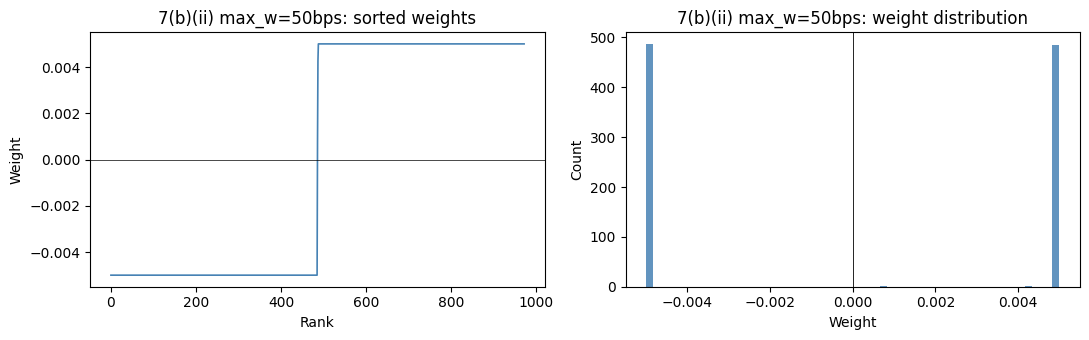

In [107]:
# --- 7(b)(ii): Max weight 50 bps ---
POS_CAP_BII = 0.005

w_bii_var = cp.Variable(n_p7)
prob_bii = cp.Problem(
    cp.Maximize(mu_p7 @ w_bii_var),
    [cp.sum(w_bii_var) == 0,
     cp.quad_form(w_bii_var, Sigma_eff) <= var_month_cap,
     cp.abs(w_bii_var) <= POS_CAP_BII]
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_bii.solve(solver=_s, verbose=False) if _s else prob_bii.solve(verbose=False)
    except Exception:
        continue
    if w_bii_var.value is not None and prob_bii.status in ("optimal", "optimal_inaccurate"):
        break

w_bii = np.asarray(w_bii_var.value, dtype=float).ravel()
n_active = int(np.sum(np.abs(w_bii) >= 0.999 * POS_CAP_BII))
print(f"7(b)(ii): Max weight 50 bps status: {prob_bii.status}  |  mu'w={float(mu_p7@w_bii):.6f}")
print(f"  sum(w)={w_bii.sum():.2e}  max|w|={np.abs(w_bii).max():.6f}  # active bounds: {n_active}")
report_portfolio(w_bii, mu_p7, r_p7, Sigma_eff, B, label="7(b)(ii) max_w=50bps")


### Written Answer (7b-ii): Discussion of 50 bps cap results

**YOUR ANSWER:**

*TODO*

7(b)(iii) status: optimal  |  mu'w=7.434070
  sum(w)=-3.11e-15  max|w|=0.100000  # active bounds: 873

========== 7(b)(iii) max_w=10% ==========
  Return on gross (exp.)    : 0.085218/mo  (102.26% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.008812/mo  (10.57% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 10.2261
  Gross exposure sum|wi|    : 87.2360

  Factor exposures (w'B):
    factor_1  : -0.034624
    factor_2  : +0.354369
    factor_3  : -0.189069
    factor_4  : +0.059894
    factor_5  : +0.199707


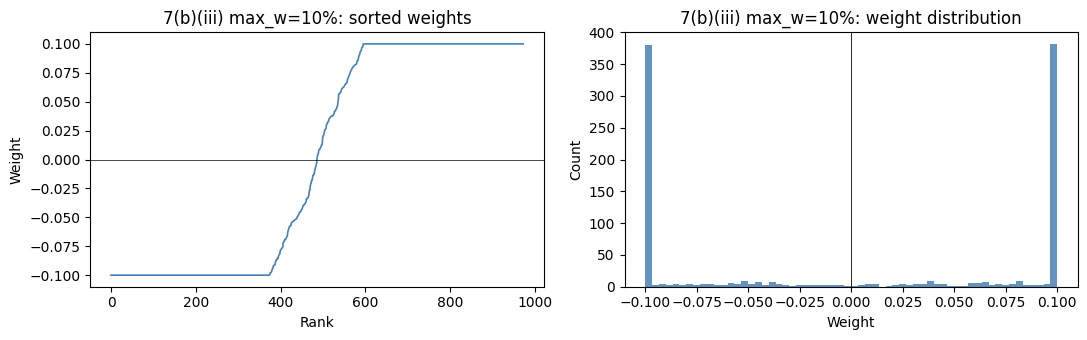

In [108]:
# --- 7(b)(iii): Max weight 10% ---
POS_CAP_BIII = 0.10

w_biii_var = cp.Variable(n_p7)
prob_biii = cp.Problem(
    cp.Maximize(mu_p7 @ w_biii_var),
    [cp.sum(w_biii_var) == 0,
     cp.quad_form(w_biii_var, Sigma_eff) <= var_month_cap,
     cp.abs(w_biii_var) <= POS_CAP_BIII]
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_biii.solve(solver=_s, verbose=False) if _s else prob_biii.solve(verbose=False)
    except Exception:
        continue
    if w_biii_var.value is not None and prob_biii.status in ("optimal", "optimal_inaccurate"):
        break

w_biii = np.asarray(w_biii_var.value, dtype=float).ravel()
n_active = int(np.sum(np.abs(w_biii) >= 0.999 * POS_CAP_BIII))
print(f"7(b)(iii): Max weight 10% status: {prob_biii.status}  |  mu'w={float(mu_p7@w_biii):.6f}")
print(f"  sum(w)={w_biii.sum():.2e}  max|w|={np.abs(w_biii).max():.6f}  # active bounds: {n_active}")
report_portfolio(w_biii, mu_p7, r_p7, Sigma_eff, B, label="7(b)(iii) max_w=10%")


### Written Answer (7b-iii): Discussion of 10% cap results

**YOUR ANSWER:**

*TODO*

### 7(c) F1 Neutrality

Adjust the optimization so that the portfolio has zero exposure to the first factor.

### Written Answer (7c): Explain in words how you would adjust the optimization to achieve an F1 neutral portfolio.

**YOUR ANSWER:**

The way we would implement F1 neutrality is to have an additional constraint that w'F1 = 0, where F1 are the estimated factor exposures to the first factor. This is a convex constraint so we will be able to utilize our existing convex optimization machine to solve this. 

7(c) status: optimal  |  mu'w=886.012822
  sum(w)=-7.11e-14  F1 exposure=7.82e-14

========== 7(c) F1-neutral ==========
  Return on gross (exp.)    : 0.249450/mo  (299.34% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005020/mo  (6.02% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 29.9340
  Gross exposure sum|wi|    : 3551.8663

  Factor exposures (w'B):
    factor_1  : -0.000000
    factor_2  : -10.728173
    factor_3  : -6.713878
    factor_4  : -40.482740
    factor_5  : +26.113025


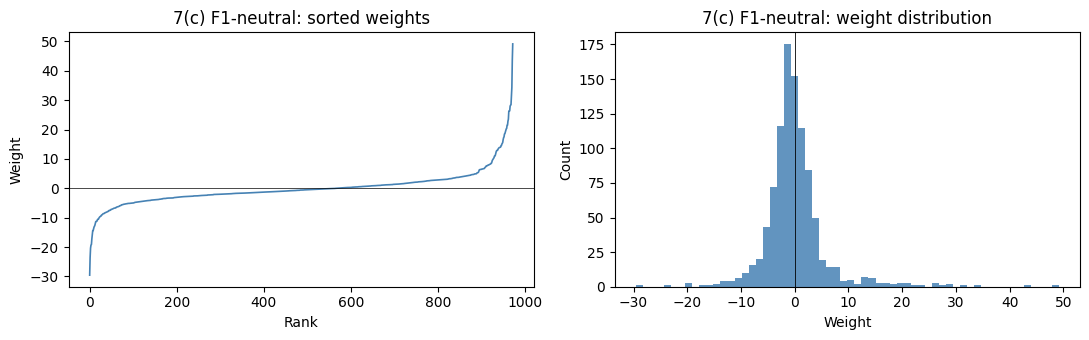

In [109]:
# --- 7(c): F1-neutral portfolio ---
# Additional constraint: B[:,0]'w == 0  (zero exposure to factor 1)

w_c_var = cp.Variable(n_p7)
prob_c = cp.Problem(
    cp.Maximize(mu_p7 @ w_c_var),
    [cp.sum(w_c_var) == 0,
     cp.quad_form(w_c_var, Sigma_eff) <= var_month_cap,
     B[:, 0] @ w_c_var == 0]
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_c.solve(solver=_s, verbose=False) if _s else prob_c.solve(verbose=False)
    except Exception:
        continue
    if w_c_var.value is not None and prob_c.status in ("optimal", "optimal_inaccurate"):
        break

w_c = np.asarray(w_c_var.value, dtype=float).ravel()
print(f"7(c) status: {prob_c.status}  |  mu'w={float(mu_p7@w_c):.6f}")
print(f"  sum(w)={w_c.sum():.2e}  F1 exposure={float(B[:,0]@w_c):.2e}")
report_portfolio(w_c, mu_p7, r_p7, Sigma_eff, B, label="7(c) F1-neutral")


### 7(d) Sector Neutrality

Use the first two digits of NAICS codes to categorize stocks by sector. Minimize exposure to sectors {52, 33, 32, 51, 54, 53, 22, 21, 56, 31}. Note: do **not** exclude corresponding securities from the investable universe.

### Written Answer (7d): Describe an approach to minimizing sector exposure.

**YOUR ANSWER:**

Here the approach to making exposure to these sectors as small as possible is to have several constrains which simply imply that the weights from companies in each of these sectors individually sum to one. So there will be one constraint per industry. Again these constraints are convex so existing convex optimization methodology will hold. 

7(d) status: optimal  |  mu'w=882.610569  |  10 sector constraints
  sum(w)=-1.99e-13
  Sector net weights (should be ~0):
    sector 52: +2.49e-14  (139 stocks)
    sector 33: -1.42e-14  (218 stocks)
    sector 32: +2.13e-14  (108 stocks)
    sector 51: +0.00e+00  (73 stocks)
    sector 54: -5.33e-15  (51 stocks)
    sector 53: +0.00e+00  (19 stocks)
    sector 22: +3.11e-15  (48 stocks)
    sector 21: +0.00e+00  (36 stocks)
    sector 56: -3.55e-15  (36 stocks)
    sector 31: +1.78e-15  (47 stocks)

========== 7(d) sector-neutral ==========
  Return on gross (exp.)    : 0.246688/mo  (296.03% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.005426/mo  (6.51% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 29.6026
  Gross exposure sum|wi|    : 3577.8379

  Factor exposures (w'B):
    factor_1  : +14.224419
    factor_2  : -30.868667
    factor_3  : -20.714483
    factor_4  : -33.380196
    factor_5  : +54.724436


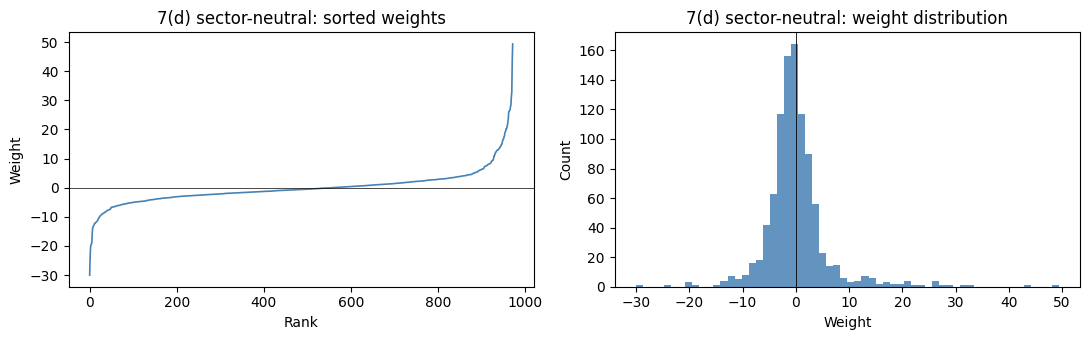

In [110]:
# --- 7(d): Sector-neutral portfolio ---
# For each target sector: sum of weights of stocks in that sector == 0
# sector_map already computed in Problem 5: first 2 digits of NAICS

TARGET_SECTORS = [52, 33, 32, 51, 54, 53, 22, 21, 56, 31]

w_d_var = cp.Variable(n_p7)

sec_constrs = []
for _sec in TARGET_SECTORS:
    _mask = (sector_map == _sec).astype(float)
    if _mask.sum() > 0:
        sec_constrs.append(_mask @ w_d_var == 0)
    else:
        print(f"  Sector {_sec}: no stocks in universe, skipping")

prob_d = cp.Problem(
    cp.Maximize(mu_p7 @ w_d_var),
    [cp.sum(w_d_var) == 0,
     cp.quad_form(w_d_var, Sigma_eff) <= var_month_cap]
    + sec_constrs
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_d.solve(solver=_s, verbose=False) if _s else prob_d.solve(verbose=False)
    except Exception:
        continue
    if w_d_var.value is not None and prob_d.status in ("optimal", "optimal_inaccurate"):
        break

w_d = np.asarray(w_d_var.value, dtype=float).ravel()
print(f"7(d) status: {prob_d.status}  |  mu'w={float(mu_p7@w_d):.6f}  |  {len(sec_constrs)} sector constraints")
print(f"  sum(w)={w_d.sum():.2e}")
print("  Sector net weights (should be ~0):")
for _sec in TARGET_SECTORS:
    _mask = (sector_map == _sec).astype(float)
    if _mask.sum() > 0:
        print(f"    sector {_sec:2d}: {float(_mask @ w_d):+.2e}  ({int(_mask.sum())} stocks)")
report_portfolio(w_d, mu_p7, r_p7, Sigma_eff, B, label="7(d) sector-neutral")


### Written Answer (7d): Discussion of sector-neutral results

**YOUR ANSWER:**

*TODO*

### 7(e) Neutrality to All Factors and Sectors

**(i)** Portfolio orthogonal to all 5 factor exposures and all sector loadings (de minimis net dollar exposure).

**(ii)** Net impact of a $2\sigma$ shock from each individual factor must be less than 10 bps of gross market value.

7(e)(i) status: optimal  |  mu'w=871.815649
  sum(w)=-2.84e-14  |  23 sector constraints
  Factor exposures (should be ~0): [-0. -0.  0.  0.  0.]

========== 7(e)(i) all-factor + all-sector neutral ==========
  Return on gross (exp.)    : 0.240573/mo  (288.69% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.004839/mo  (5.81% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 28.8688
  Gross exposure sum|wi|    : 3623.9092

  Factor exposures (w'B):
    factor_1  : -0.000000
    factor_2  : -0.000000
    factor_3  : +0.000000
    factor_4  : +0.000000
    factor_5  : +0.000000


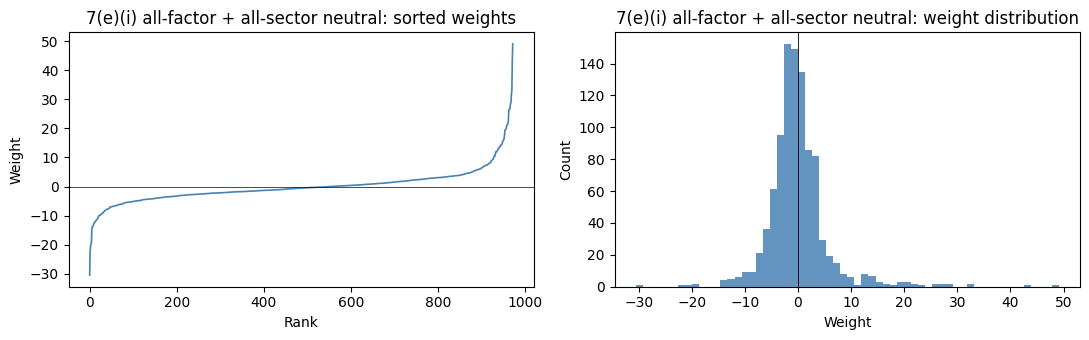

In [111]:
# --- 7(e)(i): Zero exposure to all 5 factors and all sectors ---

w_ei_var = cp.Variable(n_p7)

# Factor neutrality: B.T @ w == 0  (one constraint per factor, stacked)
# Sector neutrality: for every sector present in the universe, sum(w_i in sector) == 0
all_sectors = sorted(set(int(s) for s in sector_map if np.isfinite(s)))
sec_ei_constrs = []
for _sec in all_sectors:
    _mask = (sector_map == _sec).astype(float)
    if _mask.sum() > 0:
        sec_ei_constrs.append(_mask @ w_ei_var == 0)

prob_ei = cp.Problem(
    cp.Maximize(mu_p7 @ w_ei_var),
    [cp.sum(w_ei_var) == 0,
     cp.quad_form(w_ei_var, Sigma_eff) <= var_month_cap,
     B.T @ w_ei_var == 0]
    + sec_ei_constrs
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_ei.solve(solver=_s, verbose=False) if _s else prob_ei.solve(verbose=False)
    except Exception:
        continue
    if w_ei_var.value is not None and prob_ei.status in ("optimal", "optimal_inaccurate"):
        break

w_ei = np.asarray(w_ei_var.value, dtype=float).ravel()
fac_exp_ei = B.T @ w_ei
print(f"7(e)(i) status: {prob_ei.status}  |  mu'w={float(mu_p7@w_ei):.6f}")
print(f"  sum(w)={w_ei.sum():.2e}  |  {len(sec_ei_constrs)} sector constraints")
print(f"  Factor exposures (should be ~0): {np.array2string(fac_exp_ei, precision=2, suppress_small=True)}")
print("  Sector net weights (should be ~0):")
for _sec in all_sectors:
    _mask = (sector_map == _sec).astype(float)
    if _mask.sum() > 0:
        print(f"    sector {_sec:2d}: {float(_mask @ w_ei):+.2e}  ({int(_mask.sum())} stocks)")
report_portfolio(w_ei, mu_p7, r_p7, Sigma_eff, B, label="7(e)(i) all-factor + all-sector neutral")


### Written Answer (7e-i): Discussion of full neutrality results

**YOUR ANSWER:**

*TODO*

### Written Answer (7e-ii): Describe mathematically what the $2\sigma$ shock constraint is and why it might produce meaningfully different results from (i).

**YOUR ANSWER:**

*TODO*

In [ ]:
# --- 7(e)(ii) Option A: 2-sigma shock constraint ---
# For each factor k: |B[:,k]'w| * 2*sigma_k <= 0.001  (10 bps of GMV)
# sigma_k = sqrt(Omega_F[k,k])  from the factor covariance matrix

n_factors = B.shape[1]
sigma_factors = np.sqrt(np.diag(Omega_F))   # per-factor vol, shape (n_factors,)
SHOCK_CAP = 0.001                            # 10 bps

w_eii_var = cp.Variable(n_p7)

shock_constrs = [
    cp.abs(B[:, k] @ w_eii_var) * (2 * sigma_factors[k]) <= SHOCK_CAP
    for k in range(n_factors)
]

prob_eii = cp.Problem(
    cp.Maximize(mu_p7 @ w_eii_var),
    [cp.sum(w_eii_var) == 0,
     cp.quad_form(w_eii_var, Sigma_eff) <= var_month_cap]
    + shock_constrs
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_eii.solve(solver=_s, verbose=False) if _s else prob_eii.solve(verbose=False)
    except Exception:
        continue
    if w_eii_var.value is not None and prob_eii.status in ("optimal", "optimal_inaccurate"):
        break

w_eii = np.asarray(w_eii_var.value, dtype=float).ravel()
fac_exp_eii = B.T @ w_eii
shock_pnl   = np.abs(fac_exp_eii) * 2 * sigma_factors  # P&L per factor under 2-sigma shock

print(f"7(e)(ii) status: {prob_eii.status}  |  mu'w={float(mu_p7@w_eii):.6f}")
print(f"  sum(w)={w_eii.sum():.2e}")
print(f"  Factor shock analysis (cap = {SHOCK_CAP*1e4:.0f} bps):")
for k in range(n_factors):
    print(f"    F{k+1}: beta={fac_exp_eii[k]:+.4f}  sigma={sigma_factors[k]:.4f}"
          f"  2sigma-PnL={shock_pnl[k]*1e4:.2f} bps  {'OK' if shock_pnl[k]<=SHOCK_CAP else 'VIOLATED'}")
report_portfolio(w_eii, mu_p7, r_p7, Sigma_eff, B, label="7(e)(ii) 2-sigma shock constraint")


### Written Answer (7e-ii): Discussion of $2\sigma$ shock results / scenario analysis

**YOUR ANSWER:**

*TODO*

### 7(f) Financing

Assume: borrow at SOFR + 20 bps, earn on deposits at SOFR - 20 bps, can borrow up to 10x the amount in your prime brokerage account. Short sale proceeds are effectively a deposit.

### Written Answer (7f-i): What are your financing charges if the portfolio is dollar neutral?

**Answer:**

In a dollar-neutral portfolio the gross long exposure equals the gross short exposure, call both $X. The short sale proceeds are deposited at the prime broker, so the two financing flows are:

| Leg | Rate | Notional |
|-----|------|----------|
| Borrow cash to fund longs | Pay SOFR + 20 bps | $X |
| Short sale proceeds on deposit | Earn SOFR − 20 bps | $X |

Net financing charge = (SOFR + 20 bps) − (SOFR − 20 bps) = **40 bps on $X gross exposure**. The SOFR component cancels exactly because the two notionals are equal — you are paying the prime broker's bid-ask spread on both legs simultaneously.

Two additional considerations:
- If any short positions are **hard-to-borrow**, an extra stock borrow fee is owed to the share lender on top of the 40 bps spread.
- The 10× leverage limit is not binding here: the short proceeds self-fund the longs, so no additional borrowing against the prime brokerage account is required.

### Written Answer (7f-ii): What are your financing charges if you are 10% net short?

**Answer:**

Let the gross long notional be $L and the gross short notional be $(L + 10\%)$ (so the net short is 10% of portfolio value). All short sale proceeds are deposited at the prime broker. The two financing flows are:

| Leg | Rate | Notional |
|-----|------|----------|
| Borrow cash to fund longs | Pay SOFR + 20 bps | $L |
| All short proceeds on deposit | Earn SOFR − 20 bps | $(L + 10\%) |

Net financing charge:

23764	ext{Net charge} = (	ext{SOFR}+20	ext{bps})\cdot L - (	ext{SOFR}-20	ext{bps})\cdot(L+10\%) = 40	ext{bps}\cdot L - (	ext{SOFR}-20	ext{bps})\cdot 10\%23764

The 40 bps spread applies only to the matched long notional \ (identical to the dollar-neutral case on that portion). The net short 10% generates an additional deposit earning of (SOFR − 20 bps) × 10% which offsets the spread cost.

The sign of the net charge depends on SOFR:
- **High rates:** the deposit rebate on the 10% net short can exceed the spread cost on \, resulting in a net **rebate** (negative financing charge).
- **Low/zero rates:** the spread cost dominates and you pay a net positive charge.

The 10× leverage limit remains non-binding since the short proceeds more than cover the long positions.

### Written Answer (7f-iii): What are your financing charges if you are 10% net long?

**Answer:**

Let the gross short notional be $L and the gross long notional be $(L + 10\%)$ (net long 10%). The short proceeds only cover $L of the long book; the remaining 10% must be borrowed against the prime brokerage account:

| Leg | Rate | Notional |
|-----|------|----------|
| Borrow cash to fund matched longs | Pay SOFR + 20 bps | $L |
| Borrow cash to fund net long | Pay SOFR + 20 bps | 10% |
| Short proceeds on deposit | Earn SOFR − 20 bps | $L |

Net financing charge:

25351	ext{Net charge} = (	ext{SOFR}+20	ext{bps})\cdot(L+10\%) - (	ext{SOFR}-20	ext{bps})\cdot L = 40	ext{bps}\cdot L + (	ext{SOFR}+20	ext{bps})\cdot 10\%25351

Unlike the net short case, this is **always a positive charge** — there is no rebate scenario. The matched portion costs the same 40 bps spread as in the dollar-neutral case, and the extra 10% net long incurs the full borrow rate of (SOFR + 20 bps) with no offsetting deposit earning.

The **10× leverage limit** is also more relevant here: the net long 10% is funded by borrowing against the prime brokerage account (whose size is determined by posted collateral and short proceeds). A large net long position could consume a meaningful portion of the available borrowing capacity.

### Written Answer (7f-iv-A): You are dollar neutral with net beta exposure of 0.10 and the market drops 10%. What issues are you now facing to continue trading next period?

**Answer:**

With net beta = 0.10 and the market down 10%, the portfolio loses approximately **0.10 × 10% = 1% of NAV** from the beta exposure alone. This creates several compounding issues:

1. **Leverage breach.** The loss reduces equity (NAV) while gross exposure remains roughly unchanged, so the leverage ratio (gross / equity) rises. If you were near the prime broker's 10× limit, the 1% NAV loss can push you above it, triggering a forced delever.

2. **Margin call.** The prime broker may issue a margin call requiring additional collateral or immediate position reduction.

3. **Dollar-neutrality drift.** After the market move, high-beta longs fall more than low-beta shorts, so the portfolio is no longer exactly dollar neutral — the long book is now worth less than the short book, introducing a net short dollar exposure that must be rebalanced.

4. **Risk limit breach.** Internal risk limits on beta or VAR may now be violated, restricting new position-taking next period.

### Written Answer (7f-iv-B): List all possible actions to rectify the situation. Pros and cons of each. How does fund size and structure impact your answer?

**Answer:**

| Action | Pros | Cons |
|--------|------|------|
| **Short index futures / ETF to hedge beta** | Fast, liquid, cheap; preserves all alpha positions | Ongoing carry cost; imperfect if portfolio beta estimate is stale |
| **Proportionally reduce gross exposure (delever)** | Directly fixes leverage ratio; straightforward | Market impact and transaction costs; may be forced to sell at depressed prices |
| **Rebalance individual positions** (cut high-beta longs, cover high-beta shorts) | Preserves more alpha signal; re-aligns dollar neutrality simultaneously | More complex; higher transaction costs; takes longer to execute |
| **Raise additional capital** | Restores equity buffer without touching positions | Time-consuming; may signal distress to investors; dilutive |

**Preferred approach:** shorting index futures is typically the fastest and cheapest first response — it immediately neutralises the beta without disturbing the underlying positions. Rebalancing or delevering follows if the leverage breach is structural rather than transient.

**Impact of fund size and structure:**
- **Large fund:** individual stock rebalancing carries significant market impact, making the futures hedge far more attractive. Executing a delever at scale after a down move is costly and may itself move prices.
- **Small fund:** can rebalance positions with minimal market impact, so surgical rebalancing is more viable.
- **Leverage-constrained structure (e.g. UCITS):** may not be permitted to use futures for hedging, forcing an actual position reduction.
- **Investor redemption risk:** a down move may trigger investor redemptions, compounding the forced-delever problem regardless of which action is chosen.

### 7(g) Volume Constraints and Capacity Analysis (\$1B Portfolio)

Assume a \$1B portfolio with 10:1 leverage. Rank the five portfolio construction approaches (a)-(e) by trading capacity.

### Written Answer (7g): Rank approaches (a)-(e) by trading capacity, highest to lowest. Explain your reasoning.

**YOUR ANSWER:**

*TODO*